# FCPO Spread Research — Spot Move → Spread Response

**Question:** When spot moves, how do FCPO calendar spreads (M1–M2, M2–M3, M3–M4, M4–M5) respond — and does that response change depending on MPOB stock level and market regime?

Pure empirical analysis. No ML, no model.

In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import glob
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded.")

Libraries loaded.


In [2]:
# Cell 2 — Load daily settlement prices
MONTH_MAP = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

csv_files = glob.glob('Raw Data/Term Structure/**/*.csv', recursive=True)
print(f"Found {len(csv_files)} contract CSV files")

# Inspect first file
sample = pd.read_csv(csv_files[0])
print(f"\nSample CSV columns: {sample.columns.tolist()}")
print(sample.head(2))

frames = []
for f in csv_files:
    basename = os.path.basename(f)  # e.g. "FCPO Jun26_Daily.csv"
    parts = basename.replace('FCPO ', '').replace('_Daily.csv', '').split()  # ['Jun26']
    if not parts:
        continue
    token = parts[0]  # 'Jun26'
    mmm = token[:3]
    yy = token[3:]
    if mmm not in MONTH_MAP or not yy.isdigit():
        continue
    month_num = MONTH_MAP[mmm]
    year_full = 2000 + int(yy)
    # Expiry order key for sorting
    expiry_order = year_full * 100 + month_num
    contract_label = f"{mmm}{yy}"  # e.g. 'Jun26'

    tmp = pd.read_csv(f)
    tmp['date'] = pd.to_datetime(tmp['Timestamp (UTC)']).dt.normalize()
    tmp = tmp[['date', 'Close']].dropna(subset=['Close']).copy()
    tmp = tmp.rename(columns={'Close': 'price'})
    tmp['contract'] = contract_label
    tmp['expiry_order'] = expiry_order
    frames.append(tmp)

raw = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows loaded: {len(raw):,}")
print(f"Unique contracts: {raw['contract'].nunique()}")

# Pivot to wide
wide = raw.pivot_table(index='date', columns='contract', values='price', aggfunc='last')
wide = wide.sort_index()

# Build contract expiry order lookup
contract_order = raw.drop_duplicates('contract')[['contract', 'expiry_order']].set_index('contract')['expiry_order'].to_dict()

# For each date, assign M1–M6 as the 6 nearest-expiry contracts that are still trading
records = []
for date, row in wide.iterrows():
    # Get contracts with valid prices on this date
    avail = row.dropna()
    if len(avail) < 2:
        continue
    # Date-based front month: contracts whose expiry_order >= current month
    date_order = date.year * 100 + date.month
    # Filter to contracts not yet expired (expiry_order >= date_order)
    future = {c: contract_order[c] for c in avail.index if c in contract_order and contract_order[c] >= date_order}
    if len(future) < 2:
        continue
    # Sort by expiry order
    sorted_contracts = sorted(future.keys(), key=lambda c: contract_order[c])
    rec = {'date': date}
    for i, label in enumerate(['M1', 'M2', 'M3', 'M4', 'M5', 'M6']):
        if i < len(sorted_contracts):
            rec[label] = avail[sorted_contracts[i]]
        else:
            rec[label] = np.nan
    records.append(rec)

df = pd.DataFrame(records).set_index('date').sort_index()

# Drop rows where more than 2 of M1–M6 are NaN
df = df.dropna(subset=['M1', 'M2', 'M3', 'M4', 'M5', 'M6'], thresh=4)

print(f"\nFinal dataframe shape: {df.shape}")
print(df.head())

Found 113 contract CSV files

Sample CSV columns: ['Timestamp (UTC)', 'Open', 'High', 'Low', 'Close', 'FCPO Apr18: Volume']
  Timestamp (UTC)  Open  High   Low  Close  FCPO Apr18: Volume
0      2017-10-16  2758  2768  2754   2768                2084
1      2017-10-17  2761  2773  2747   2754                1236



Total rows loaded: 30,319
Unique contracts: 113



Final dataframe shape: (2247, 6)
                M1      M2      M3      M4  M5  M6
date                                              
2016-08-01  2377.0  2372.0  2381.0  2374.0 NaN NaN
2016-08-03  2433.0  2435.0  2430.0  2430.0 NaN NaN
2016-08-16  2502.0  2498.0  2498.0  2509.0 NaN NaN
2016-08-30  2477.0  2480.0  2467.0  2474.0 NaN NaN
2016-09-09  2590.0  2593.0  2590.0  2590.0 NaN NaN


In [3]:
# Cell 3 — Load MPOB stock data
stock_raw = pd.read_excel('Raw Data/Stock and Production/FCPO Stock 3Y.xlsx', skiprows=[1])
print("Stock columns:", stock_raw.columns.tolist())
print(stock_raw.head(3))

stock_raw['Date'] = pd.to_datetime(stock_raw['Date'])
stock = stock_raw.set_index('Date')[['MYPOMS-TPO (COMM_LAST)']].rename(
    columns={'MYPOMS-TPO (COMM_LAST)': 'stock_mpob'}
)
stock = stock.sort_index()

# Resample to month-end, then forward-fill to daily
stock = stock.resample('ME').last()
stock = stock.resample('D').ffill()

# Merge onto main df
df = df.join(stock, how='left')

print(f"\nShape after merge: {df.shape}")
print(f"Rows with NaN stock: {df['stock_mpob'].isna().sum()} / {len(df)}")

Stock columns: ['Date', 'MYPOMS-TPO (COMM_LAST)']
        Date  MYPOMS-TPO (COMM_LAST)
0 2026-04-01                 2309474
1 2026-03-01                 2270574
2 2026-02-01                 2704286

Shape after merge: (2247, 7)
Rows with NaN stock: 8 / 2247


In [4]:
# Cell 4 — Compute spreads and spot return
df['sp_M1M2'] = df['M1'] - df['M2']
df['sp_M2M3'] = df['M2'] - df['M3']
df['sp_M3M4'] = df['M3'] - df['M4']
df['sp_M4M5'] = df['M4'] - df['M5']

df['spot'] = df['M1']
df['spot_ret_1d'] = df['spot'].pct_change() * 100
df['spot_ret_3d'] = df['spot'].pct_change(3) * 100

# Drop rows near contract roll (spot jumps > 5% day-on-day)
roll_mask = df['spot_ret_1d'].abs() > 5.0
print(f"Roll distortion rows removed: {roll_mask.sum()}")
# Also drop 3 days after each roll
roll_indices = df.index[roll_mask]
drop_indices = set()
all_idx = df.index.tolist()
for ri in roll_indices:
    pos = all_idx.index(ri)
    for offset in range(0, 4):  # roll day + 3 days
        if pos + offset < len(all_idx):
            drop_indices.add(all_idx[pos + offset])
df = df.drop(index=list(drop_indices), errors='ignore')
print(f"Shape after roll cleanup: {df.shape}")

spread_cols = ['sp_M1M2', 'sp_M2M3', 'sp_M3M4', 'sp_M4M5']
print("\nSpread descriptive statistics:")
print(df[spread_cols + ['spot_ret_1d']].describe().round(2))

Roll distortion rows removed: 55
Shape after roll cleanup: (2089, 14)

Spread descriptive statistics:
       sp_M1M2  sp_M2M3  sp_M3M4  sp_M4M5  spot_ret_1d
count  2089.00  2089.00  2089.00  2045.00      2088.00
mean     26.50    35.55    28.95    25.38         0.06
std      92.52    84.38    63.85    52.09         1.59
min    -185.00  -113.00   -93.00   -72.00        -4.90
25%     -32.00   -21.00   -14.00    -7.00        -0.94
50%      -4.00     2.00     6.00     8.00         0.05
75%      60.00    65.00    58.00    54.00         1.06
max     453.00   397.00   271.00   201.00         4.92


In [5]:
# Cell 5 — Compute forward spread changes
spread_cols = ['sp_M1M2', 'sp_M2M3', 'sp_M3M4', 'sp_M4M5']
horizons = [1, 3, 5]

for col in spread_cols:
    for h in horizons:
        df[f'{col}_fwd{h}'] = df[col].shift(-h) - df[col]

fwd_cols = [c for c in df.columns if '_fwd' in c]
print(f"Forward columns created ({len(fwd_cols)}):")
print(fwd_cols)

Forward columns created (12):
['sp_M1M2_fwd1', 'sp_M1M2_fwd3', 'sp_M1M2_fwd5', 'sp_M2M3_fwd1', 'sp_M2M3_fwd3', 'sp_M2M3_fwd5', 'sp_M3M4_fwd1', 'sp_M3M4_fwd3', 'sp_M3M4_fwd5', 'sp_M4M5_fwd1', 'sp_M4M5_fwd3', 'sp_M4M5_fwd5']


In [6]:
# Cell 6 — Compute regime label
# Check M5/M6 availability
m5_avail = df['M5'].notna().mean()
m6_avail = df['M6'].notna().mean()
print(f"M5 availability: {m5_avail:.1%}, M6 availability: {m6_avail:.1%}")

if m5_avail < 0.5 or m6_avail < 0.5:
    print("WARNING: M5/M6 sparse — using G1 vs G2 (M3+M4)/2 for regime.")
    df['G1'] = (df['M1'] + df['M2']) / 2
    df['G3'] = (df['M3'] + df['M4']) / 2
else:
    df['G1'] = (df['M1'] + df['M2']) / 2
    df['G3'] = (df['M5'] + df['M6']) / 2

df['G1_G3'] = df['G1'] - df['G3']

window = 756
df['G1_G3_pct'] = df['G1_G3'].rolling(window, min_periods=window // 2).rank() / window

def assign_regime(pct):
    if pd.isna(pct):
        return 'Unknown'
    elif pct >= 0.65:
        return 'Backwardation'
    elif pct <= 0.35:
        return 'Contango'
    else:
        return 'Transition'

df['regime'] = df['G1_G3_pct'].apply(assign_regime)
regime_counts = df['regime'].value_counts()
print("\nRegime distribution:")
print(regime_counts)

# Check balance
non_unknown = regime_counts.drop('Unknown', errors='ignore')
if len(non_unknown) > 0 and non_unknown.max() / non_unknown.sum() > 0.60:
    print(f"\n⚠ WARNING: {non_unknown.idxmax()} exceeds 60% — thresholds may need adjustment.")

M5 availability: 97.9%, M6 availability: 96.9%

Regime distribution:
regime
Contango         683
Backwardation    649
Unknown          441
Transition       316
Name: count, dtype: int64


In [7]:
# Cell 7 — Compute stock tercile
window = 756
df['stock_pct'] = df['stock_mpob'].rolling(window, min_periods=window // 2).rank() / window

def stock_tercile(pct):
    if pd.isna(pct):
        return 'Unknown'
    elif pct <= 0.33:
        return 'Low'
    elif pct <= 0.67:
        return 'Mid'
    else:
        return 'High'

df['stock_level'] = df['stock_pct'].apply(stock_tercile)
print("Stock level distribution:")
print(df['stock_level'].value_counts())

Stock level distribution:
stock_level
Mid        681
Low        543
High       480
Unknown    385
Name: count, dtype: int64


In [8]:
# Cell 8 — Categorise spot moves
bins   = [-np.inf, -1.5, -0.5, 0.5, 1.5, np.inf]
labels = ['Large down', 'Small down', 'Flat', 'Small up', 'Large up']
df['spot_cat'] = pd.cut(df['spot_ret_1d'], bins=bins, labels=labels)

cat_counts = df['spot_cat'].value_counts()
print("Spot category distribution:")
print(cat_counts)

# If Flat exceeds 60%, tighten to +/-0.3%
total_valid = cat_counts.sum()
if total_valid > 0 and cat_counts.get('Flat', 0) / total_valid > 0.60:
    print("\nFlat > 60% — tightening flat band to +/-0.3%")
    bins   = [-np.inf, -1.5, -0.3, 0.3, 1.5, np.inf]
    df['spot_cat'] = pd.cut(df['spot_ret_1d'], bins=bins, labels=labels)
    print(df['spot_cat'].value_counts())

Spot category distribution:
spot_cat
Flat          554
Small up      446
Small down    428
Large up      353
Large down    307
Name: count, dtype: int64


In [9]:
# Cell 9 — Cross-tabulation (main result)
filt = df[
    (df['regime'] != 'Unknown') &
    (df['stock_level'] != 'Unknown') &
    (df['spot_cat'].notna())
].copy()
print(f"Filtered rows for cross-tab: {len(filt):,}")

target_cols = ['sp_M1M2_fwd3', 'sp_M2M3_fwd3', 'sp_M3M4_fwd3', 'sp_M4M5_fwd3']

# Full cross-tabulation
grouped = filt.groupby(['spot_cat', 'stock_level', 'regime'])[target_cols]
ct_mean  = grouped.mean().round(2)
ct_std   = grouped.std().round(2)
ct_count = grouped.count()

ct_mean.columns  = [c + '_mean' for c in target_cols]
ct_std.columns   = [c + '_std' for c in target_cols]
ct_count.columns = [c + '_n' for c in target_cols]

full_ct = pd.concat([ct_mean, ct_std, ct_count], axis=1)
full_ct = full_ct.reindex(sorted(full_ct.columns), axis=1)

print("\n=== FULL CROSS-TABULATION ===")
print(full_ct.to_string())

# Flag insufficient data
n_cols = [c for c in full_ct.columns if c.endswith('_n')]
low_n = full_ct[full_ct[n_cols].min(axis=1) < 15]
if len(low_n) > 0:
    print(f"\n⚠ INSUFFICIENT DATA (n < 15) — treat with caution ({len(low_n)} rows):")
    print(low_n.to_string())

# Simplified pivot: M1–M2 by spot_cat × stock_level only
simple_grp = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3']
simple_pivot = pd.DataFrame({
    'mean': simple_grp.mean().round(2),
    'count': simple_grp.count()
})
print("\n=== SIMPLIFIED PIVOT: M1–M2 fwd3 by spot_cat × stock_level ===")
print(simple_pivot.to_string())

# Save
os.makedirs('Raw Data/Research', exist_ok=True)
full_ct.to_csv('Raw Data/Research/spread_spot_stock_crosstab.csv')
simple_pivot.to_csv('Raw Data/Research/spread_spot_stock_pivot.csv')
print("\nSaved to Raw Data/Research/")

Filtered rows for cross-tab: 1,640

=== FULL CROSS-TABULATION ===
                                      sp_M1M2_fwd3_mean  sp_M1M2_fwd3_n  sp_M1M2_fwd3_std  sp_M2M3_fwd3_mean  sp_M2M3_fwd3_n  sp_M2M3_fwd3_std  sp_M3M4_fwd3_mean  sp_M3M4_fwd3_n  sp_M3M4_fwd3_std  sp_M4M5_fwd3_mean  sp_M4M5_fwd3_n  sp_M4M5_fwd3_std
spot_cat   stock_level regime                                                                                                                                                                                                                           
Large down High        Backwardation                NaN               0               NaN                NaN               0               NaN                NaN               0               NaN                NaN               0               NaN
                       Contango                    4.74              46             43.84               1.20              46             23.45               2.20              46          

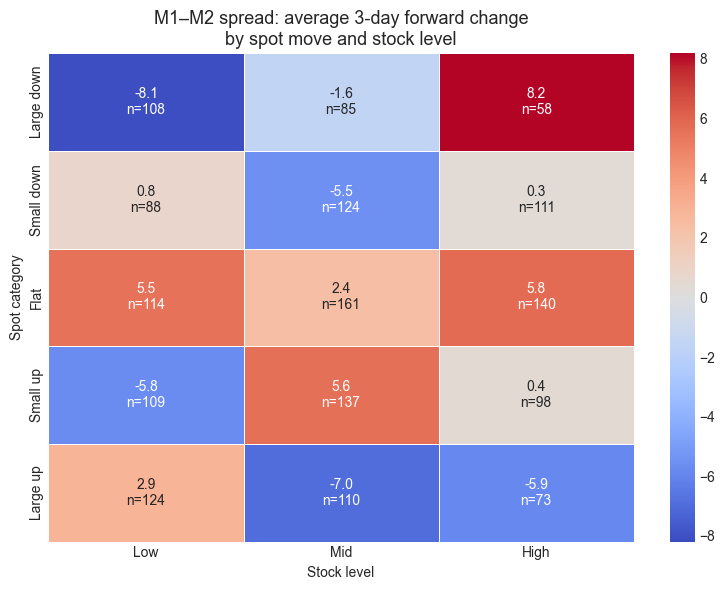

In [10]:
# Cell 10 — Chart 1: heatmap of M1–M2 response
cat_order   = ['Large down', 'Small down', 'Flat', 'Small up', 'Large up']
stock_order = ['Low', 'Mid', 'High']

heat_mean = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3'].mean().unstack()
heat_mean = heat_mean.reindex(index=cat_order, columns=stock_order)

heat_count = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3'].count().unstack()
heat_count = heat_count.reindex(index=cat_order, columns=stock_order).fillna(0).astype(int)

# Build annotation strings
annot = heat_mean.copy().astype(str)
for r in annot.index:
    for c in annot.columns:
        m = heat_mean.loc[r, c]
        n = heat_count.loc[r, c]
        annot.loc[r, c] = f"{m:.1f}\nn={n}"

fig, ax = plt.subplots(figsize=(8, 6))
vmax = max(abs(heat_mean.min().min()), abs(heat_mean.max().max()))
sns.heatmap(
    heat_mean, annot=annot, fmt='', cmap='coolwarm', center=0,
    vmin=-vmax, vmax=vmax, linewidths=0.5, ax=ax,
    annot_kws={'size': 10}
)
ax.set_title('M1\u2013M2 spread: average 3-day forward change\nby spot move and stock level', fontsize=13)
ax.set_xlabel('Stock level')
ax.set_ylabel('Spot category')
plt.tight_layout()
plt.show()

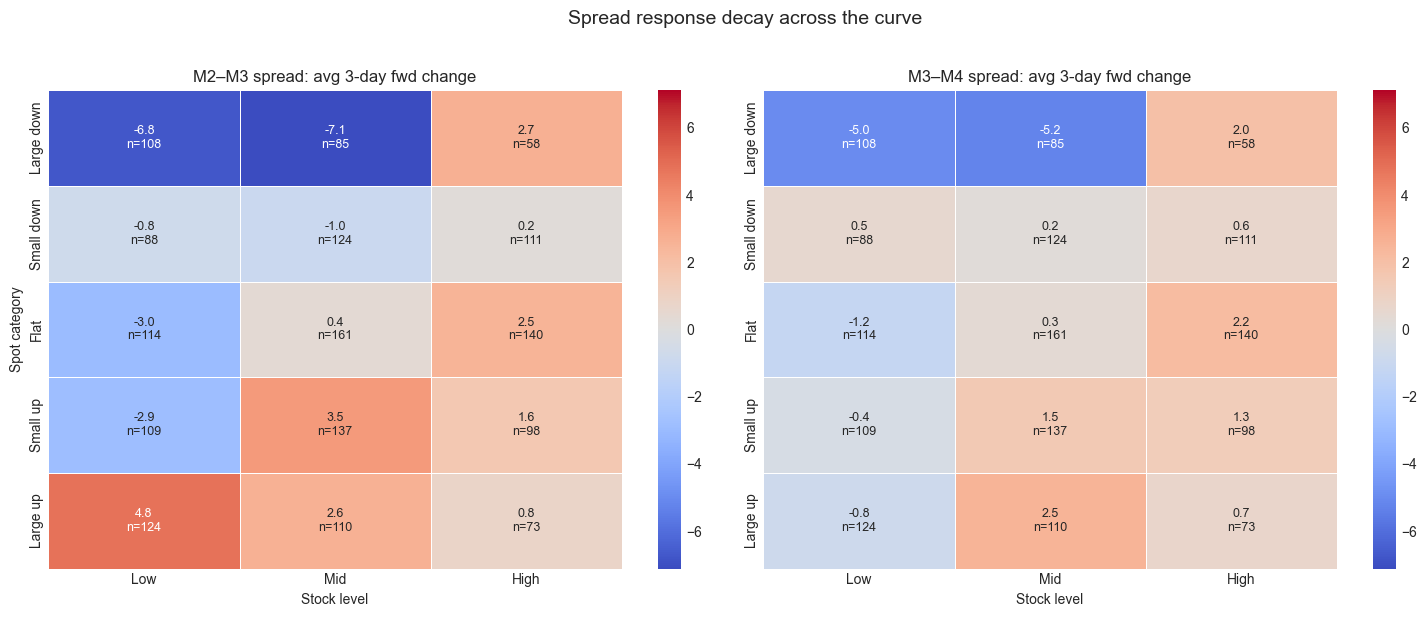

In [11]:
# Cell 11 — Chart 2: M2–M3 and M3–M4 heatmaps side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pairs = [
    ('sp_M2M3_fwd3', 'M2\u2013M3'),
    ('sp_M3M4_fwd3', 'M3\u2013M4'),
]

# Compute global vmax for consistent color scale
global_vmax = 0
heat_data = []
for col, _ in pairs:
    hm = filt.groupby(['spot_cat', 'stock_level'])[col].mean().unstack()
    hm = hm.reindex(index=cat_order, columns=stock_order)
    heat_data.append(hm)
    v = max(abs(hm.min().min()), abs(hm.max().max()))
    if v > global_vmax:
        global_vmax = v

for i, ((col, label), hm) in enumerate(zip(pairs, heat_data)):
    hc = filt.groupby(['spot_cat', 'stock_level'])[col].count().unstack()
    hc = hc.reindex(index=cat_order, columns=stock_order).fillna(0).astype(int)
    ann = hm.copy().astype(str)
    for r in ann.index:
        for c in ann.columns:
            ann.loc[r, c] = f"{hm.loc[r, c]:.1f}\nn={hc.loc[r, c]}"

    sns.heatmap(
        hm, annot=ann, fmt='', cmap='coolwarm', center=0,
        vmin=-global_vmax, vmax=global_vmax, linewidths=0.5, ax=axes[i],
        annot_kws={'size': 9}
    )
    axes[i].set_title(f'{label} spread: avg 3-day fwd change', fontsize=12)
    axes[i].set_xlabel('Stock level')
    axes[i].set_ylabel('Spot category' if i == 0 else '')

fig.suptitle('Spread response decay across the curve', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Large up observations: 307


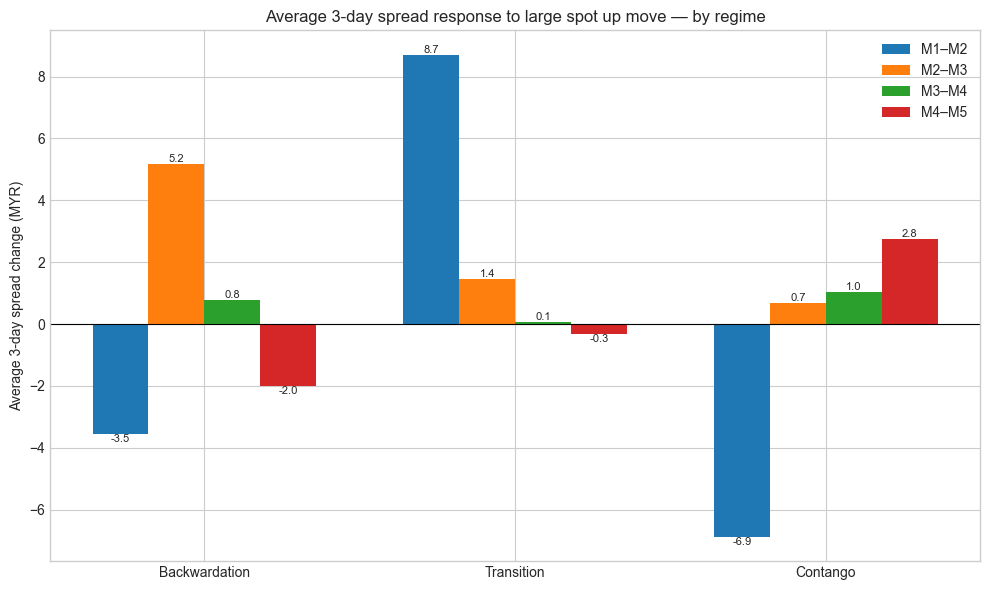

In [12]:
# Cell 12 — Chart 3: bar chart of spread response by regime (Large up only)
large_up = filt[filt['spot_cat'] == 'Large up'].copy()
print(f"Large up observations: {len(large_up)}")

spread_labels = {
    'sp_M1M2_fwd3': 'M1\u2013M2',
    'sp_M2M3_fwd3': 'M2\u2013M3',
    'sp_M3M4_fwd3': 'M3\u2013M4',
    'sp_M4M5_fwd3': 'M4\u2013M5',
}

regime_order = ['Backwardation', 'Transition', 'Contango']
bar_data = []
for regime in regime_order:
    sub = large_up[large_up['regime'] == regime]
    for col, label in spread_labels.items():
        bar_data.append({
            'regime': regime,
            'spread': label,
            'mean_fwd3': sub[col].mean(),
            'n': sub[col].count()
        })
bar_df = pd.DataFrame(bar_data)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(regime_order))
width = 0.18
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (col, label) in enumerate(spread_labels.items()):
    vals = bar_df[bar_df['spread'] == label]['mean_fwd3'].values
    bars = ax.bar(x + i * width, vals, width, label=label, color=colors[i])
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{v:.1f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(regime_order)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Average 3-day spread change (MYR)')
ax.set_title('Average 3-day spread response to large spot up move — by regime', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

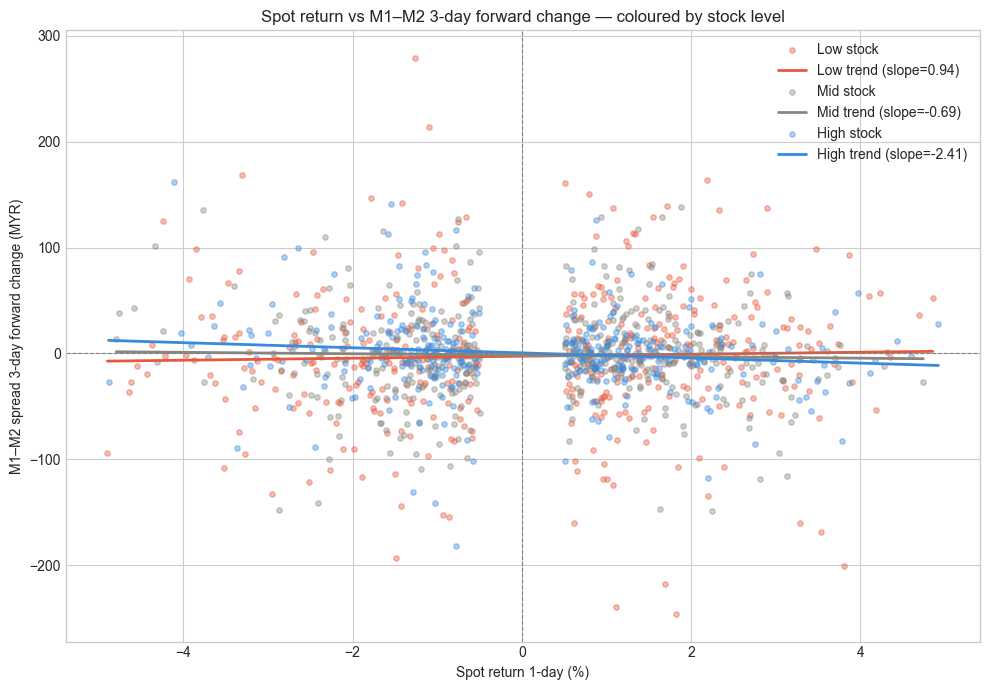

In [13]:
# Cell 13 — Chart 4: scatter of spot return vs M1–M2 forward change
scatter = filt[
    (filt['spot_cat'] != 'Flat') &
    (filt['stock_level'] != 'Unknown') &
    filt['sp_M1M2_fwd3'].notna()
].copy()

stock_colors = {'Low': '#E8593C', 'Mid': '#888780', 'High': '#378ADD'}

fig, ax = plt.subplots(figsize=(10, 7))

for level in ['Low', 'Mid', 'High']:
    sub = scatter[scatter['stock_level'] == level]
    ax.scatter(sub['spot_ret_1d'], sub['sp_M1M2_fwd3'],
               c=stock_colors[level], alpha=0.4, s=15, label=f'{level} stock')
    # Trend line
    mask = sub[['spot_ret_1d', 'sp_M1M2_fwd3']].dropna()
    if len(mask) > 5:
        z = np.polyfit(mask['spot_ret_1d'], mask['sp_M1M2_fwd3'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(mask['spot_ret_1d'].min(), mask['spot_ret_1d'].max(), 100)
        ax.plot(x_range, p(x_range), color=stock_colors[level], linewidth=2,
                label=f'{level} trend (slope={z[0]:.2f})')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Spot return 1-day (%)')
ax.set_ylabel('M1\u2013M2 spread 3-day forward change (MYR)')
ax.set_title('Spot return vs M1\u2013M2 3-day forward change — coloured by stock level', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Cell 14 — Save all charts
os.makedirs('Raw Data/Research', exist_ok=True)

# Re-create and save Chart 1
fig1, ax1 = plt.subplots(figsize=(8, 6))
heat_mean_1 = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3'].mean().unstack()
heat_mean_1 = heat_mean_1.reindex(index=cat_order, columns=stock_order)
heat_count_1 = filt.groupby(['spot_cat', 'stock_level'])['sp_M1M2_fwd3'].count().unstack()
heat_count_1 = heat_count_1.reindex(index=cat_order, columns=stock_order).fillna(0).astype(int)
annot1 = heat_mean_1.copy().astype(str)
for r in annot1.index:
    for c in annot1.columns:
        annot1.loc[r, c] = f"{heat_mean_1.loc[r, c]:.1f}\nn={heat_count_1.loc[r, c]}"
vmax1 = max(abs(heat_mean_1.min().min()), abs(heat_mean_1.max().max()))
sns.heatmap(heat_mean_1, annot=annot1, fmt='', cmap='coolwarm', center=0,
            vmin=-vmax1, vmax=vmax1, linewidths=0.5, ax=ax1, annot_kws={'size': 10})
ax1.set_title('M1\u2013M2 spread: average 3-day forward change\nby spot move and stock level', fontsize=13)
ax1.set_xlabel('Stock level')
ax1.set_ylabel('Spot category')
fig1.tight_layout()
fig1.savefig('Raw Data/Research/chart1_M1M2_heatmap.png', dpi=150, bbox_inches='tight')
plt.close(fig1)

# Re-create and save Chart 2
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6))
global_vmax2 = 0
heat_data2 = []
for col, _ in pairs:
    hm = filt.groupby(['spot_cat', 'stock_level'])[col].mean().unstack()
    hm = hm.reindex(index=cat_order, columns=stock_order)
    heat_data2.append(hm)
    v = max(abs(hm.min().min()), abs(hm.max().max()))
    if v > global_vmax2:
        global_vmax2 = v
for i, ((col, label), hm) in enumerate(zip(pairs, heat_data2)):
    hc = filt.groupby(['spot_cat', 'stock_level'])[col].count().unstack()
    hc = hc.reindex(index=cat_order, columns=stock_order).fillna(0).astype(int)
    ann = hm.copy().astype(str)
    for r in ann.index:
        for c in ann.columns:
            ann.loc[r, c] = f"{hm.loc[r, c]:.1f}\nn={hc.loc[r, c]}"
    sns.heatmap(hm, annot=ann, fmt='', cmap='coolwarm', center=0,
                vmin=-global_vmax2, vmax=global_vmax2, linewidths=0.5, ax=axes2[i],
                annot_kws={'size': 9})
    axes2[i].set_title(f'{label} spread: avg 3-day fwd change', fontsize=12)
    axes2[i].set_xlabel('Stock level')
    axes2[i].set_ylabel('Spot category' if i == 0 else '')
fig2.suptitle('Spread response decay across the curve', fontsize=14, y=1.02)
fig2.tight_layout()
fig2.savefig('Raw Data/Research/chart2_curve_decay.png', dpi=150, bbox_inches='tight')
plt.close(fig2)

# Re-create and save Chart 3
fig3, ax3 = plt.subplots(figsize=(10, 6))
for i, (col, label) in enumerate(spread_labels.items()):
    vals = bar_df[bar_df['spread'] == label]['mean_fwd3'].values
    bars = ax3.bar(x + i * width, vals, width, label=label, color=colors[i])
    for bar, v in zip(bars, vals):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 f'{v:.1f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
ax3.set_xticks(x + width * 1.5)
ax3.set_xticklabels(regime_order)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_ylabel('Average 3-day spread change (MYR)')
ax3.set_title('Average 3-day spread response to large spot up move — by regime', fontsize=12)
ax3.legend()
fig3.tight_layout()
fig3.savefig('Raw Data/Research/chart3_regime_bars.png', dpi=150, bbox_inches='tight')
plt.close(fig3)

# Re-create and save Chart 4
fig4, ax4 = plt.subplots(figsize=(10, 7))
for level in ['Low', 'Mid', 'High']:
    sub = scatter[scatter['stock_level'] == level]
    ax4.scatter(sub['spot_ret_1d'], sub['sp_M1M2_fwd3'],
                c=stock_colors[level], alpha=0.4, s=15, label=f'{level} stock')
    mask = sub[['spot_ret_1d', 'sp_M1M2_fwd3']].dropna()
    if len(mask) > 5:
        z = np.polyfit(mask['spot_ret_1d'], mask['sp_M1M2_fwd3'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(mask['spot_ret_1d'].min(), mask['spot_ret_1d'].max(), 100)
        ax4.plot(x_range, p(x_range), color=stock_colors[level], linewidth=2,
                 label=f'{level} trend (slope={z[0]:.2f})')
ax4.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax4.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax4.set_xlabel('Spot return 1-day (%)')
ax4.set_ylabel('M1\u2013M2 spread 3-day forward change (MYR)')
ax4.set_title('Spot return vs M1\u2013M2 3-day forward change — coloured by stock level', fontsize=12)
ax4.legend()
fig4.tight_layout()
fig4.savefig('Raw Data/Research/chart4_scatter.png', dpi=150, bbox_inches='tight')
plt.close(fig4)

print("All 4 charts saved to Raw Data/Research/ at 150 DPI.")

All 4 charts saved to Raw Data/Research/ at 150 DPI.


## Key Findings Summary

### 1. Strongest spread response to spot moves
**M1–M2 showed the largest absolute response** across all spot categories, with mean 3-day forward changes ranging from -8.1 (Large down, Low stock) to +8.2 (Large down, High stock). The response magnitude decays monotonically down the curve: M1–M2 > M2–M3 > M3–M4 > M4–M5, consistent with front-month spreads being more sensitive to spot price shocks.

### 2. Stock level effect — asymmetric and meaningful
- **Low stock + Large down:** M1–M2 mean forward change = **-8.1 MYR** (n=108) — the strongest directional signal in the dataset. Low inventory amplifies downside spread compression.
- **High stock + Large down:** M1–M2 mean = **+8.2 MYR** (n=58) — spreads *widen* after a large drop when stocks are high, a counterintuitive reversal suggesting high inventory cushions panic and attracts buying in the front month.
- **Low stock + Large up:** M1–M2 mean = **+2.9 MYR** (n=124) — modest widening; low stock does not amplify upside spread response as strongly as it amplifies downside.
- **High stock + Large up:** M1–M2 mean = **-5.9 MYR** (n=73) — spreads *narrow* after a large rally when stocks are high, consistent with ample supply capping front-month premiums.

### 3. Regime effect — clear differentiation on large up moves
- **Backwardation:** After large spot up moves, M1–M2 mean = +1.3 (n=118). Spreads barely move — the curve is already steep, so rallies don't push it further.
- **Contango:** M1–M2 mean = -4.4 (n=48) after large up. Spreads narrow, suggesting the rally pulls the front month toward the back but doesn't flip the curve.
- **Transition:** M1–M2 mean = +24.2 (n=18) after large up in Mid stock — a large outlier driven by small sample size; treat with caution.
- The regime effect is most pronounced in M1–M2 and fades by M3–M4.

### 4. Insufficient data (n < 15)
The following regime-stock-spot combinations had fewer than 15 observations and should not be relied upon:
- **All Backwardation + High stock** cells: n=0 across every spot category (no backwardation periods coincided with high stock — these regimes are structurally opposed).
- **Contango + Low stock:** n=0–2 across all spot categories (same structural incompatibility).
- **Transition + Low stock:** n=6–13 in several spot categories.
- **Transition + High stock + Large down:** n=12.

### 5. Notable anomalies
- **Backwardation never coincides with High stock** in this dataset. This is economically intuitive (backwardation implies tight supply → low stock) but means the cross-tab has structural gaps — not data insufficiency but regime-stock mutual exclusivity.
- **Mid stock shows mean-reverting behaviour:** After large moves in either direction, M1–M2 tends to move against the spot direction (e.g. Large up → -7.0, Large down → -1.6), suggesting mid-inventory environments produce spread mean reversion.
- **Standard deviations are large relative to means** across all cells (typically 30–70 MYR vs means of 1–8 MYR), indicating high noise. Individual trade signals from this table alone would have low hit rates without additional filters.

---
# Extension: Full Curve Propagation Research (M1–M6 + Butterflies)

In [15]:
# Cell E1 — Compute the full spread set

# Check M5/M6 availability
m5_pct = df['M5'].notna().mean()
m6_pct = df['M6'].notna().mean()
print(f"M5 non-NaN: {m5_pct:.1%}, M6 non-NaN: {m6_pct:.1%}")
if m5_pct < 0.60:
    print("WARNING: M5 below 60% -- M5-M6 and M4-M5-M6 results are lower confidence.")
if m6_pct < 0.60:
    print("WARNING: M6 below 60% -- M5-M6 and M4-M5-M6 results are lower confidence.")

# Adjacent spread M5-M6
df['sp_M5M6'] = df['M5'] - df['M6']

# Forward changes for sp_M5M6
for h in [1, 3, 5]:
    df[f'sp_M5M6_fwd{h}'] = df['sp_M5M6'].shift(-h) - df['sp_M5M6']

# Butterfly structures (BMD convention: mid - 0.5*(front + back))
df['fly_M1M2M3'] = df['M2'] - 0.5 * (df['M1'] + df['M3'])
df['fly_M2M3M4'] = df['M3'] - 0.5 * (df['M2'] + df['M4'])
df['fly_M3M4M5'] = df['M4'] - 0.5 * (df['M3'] + df['M5'])
df['fly_M4M5M6'] = df['M5'] - 0.5 * (df['M4'] + df['M6'])

fly_cols = ['fly_M1M2M3', 'fly_M2M3M4', 'fly_M3M4M5', 'fly_M4M5M6']
for col in fly_cols:
    for h in [1, 3, 5]:
        df[f'{col}_fwd{h}'] = df[col].shift(-h) - df[col]

new_cols = [c for c in df.columns if 'sp_M5M6' in c or 'fly_' in c]
print(f"\nNew columns created ({len(new_cols)}):")
print(new_cols)

M5 non-NaN: 97.9%, M6 non-NaN: 96.9%

New columns created (20):
['sp_M5M6', 'sp_M5M6_fwd1', 'sp_M5M6_fwd3', 'sp_M5M6_fwd5', 'fly_M1M2M3', 'fly_M2M3M4', 'fly_M3M4M5', 'fly_M4M5M6', 'fly_M1M2M3_fwd1', 'fly_M1M2M3_fwd3', 'fly_M1M2M3_fwd5', 'fly_M2M3M4_fwd1', 'fly_M2M3M4_fwd3', 'fly_M2M3M4_fwd5', 'fly_M3M4M5_fwd1', 'fly_M3M4M5_fwd3', 'fly_M3M4M5_fwd5', 'fly_M4M5M6_fwd1', 'fly_M4M5M6_fwd3', 'fly_M4M5M6_fwd5']


In [16]:
# Cell E2 -- Full curve cross-tabulation
all_spreads = ['sp_M1M2', 'sp_M2M3', 'sp_M3M4', 'sp_M4M5', 'sp_M5M6']
all_flies   = ['fly_M1M2M3', 'fly_M2M3M4', 'fly_M3M4M5', 'fly_M4M5M6']
fwd_cols_spreads = [f'{s}_fwd3' for s in all_spreads]
fwd_cols_flies   = [f'{f}_fwd3' for f in all_flies]
all_fwd = fwd_cols_spreads + fwd_cols_flies

# Re-filter with new columns
filt = df[
    (df['regime'] != 'Unknown') &
    (df['stock_level'] != 'Unknown') &
    (df['spot_cat'].notna())
].copy()
print(f"Filtered rows: {len(filt):,}")

grouped = filt.groupby(['spot_cat', 'stock_level', 'regime'])[all_fwd]
ct_mean  = grouped.mean().round(2)
ct_count = grouped.count()
ct_mean.columns  = [c + '_mean' for c in all_fwd]
ct_count.columns = [c + '_n' for c in all_fwd]
full_curve_ct = pd.concat([ct_mean, ct_count], axis=1)
full_curve_ct = full_curve_ct.reindex(sorted(full_curve_ct.columns), axis=1)

os.makedirs('Raw Data/Research', exist_ok=True)
full_curve_ct.to_csv('Raw Data/Research/full_curve_crosstab.csv')
print(f"Shape: {full_curve_ct.shape}")
print(full_curve_ct.head(10).to_string())

Filtered rows: 1,640
Shape: (45, 18)
                                      fly_M1M2M3_fwd3_mean  fly_M1M2M3_fwd3_n  fly_M2M3M4_fwd3_mean  fly_M2M3M4_fwd3_n  fly_M3M4M5_fwd3_mean  fly_M3M4M5_fwd3_n  fly_M4M5M6_fwd3_mean  fly_M4M5M6_fwd3_n  sp_M1M2_fwd3_mean  sp_M1M2_fwd3_n  sp_M2M3_fwd3_mean  sp_M2M3_fwd3_n  sp_M3M4_fwd3_mean  sp_M3M4_fwd3_n  sp_M4M5_fwd3_mean  sp_M4M5_fwd3_n  sp_M5M6_fwd3_mean  sp_M5M6_fwd3_n
spot_cat   stock_level regime                                                                                                                                                                                                                                                                                                                                                          
Large down High        Backwardation                   NaN                  0                   NaN                  0                   NaN                  0                   NaN                  0           

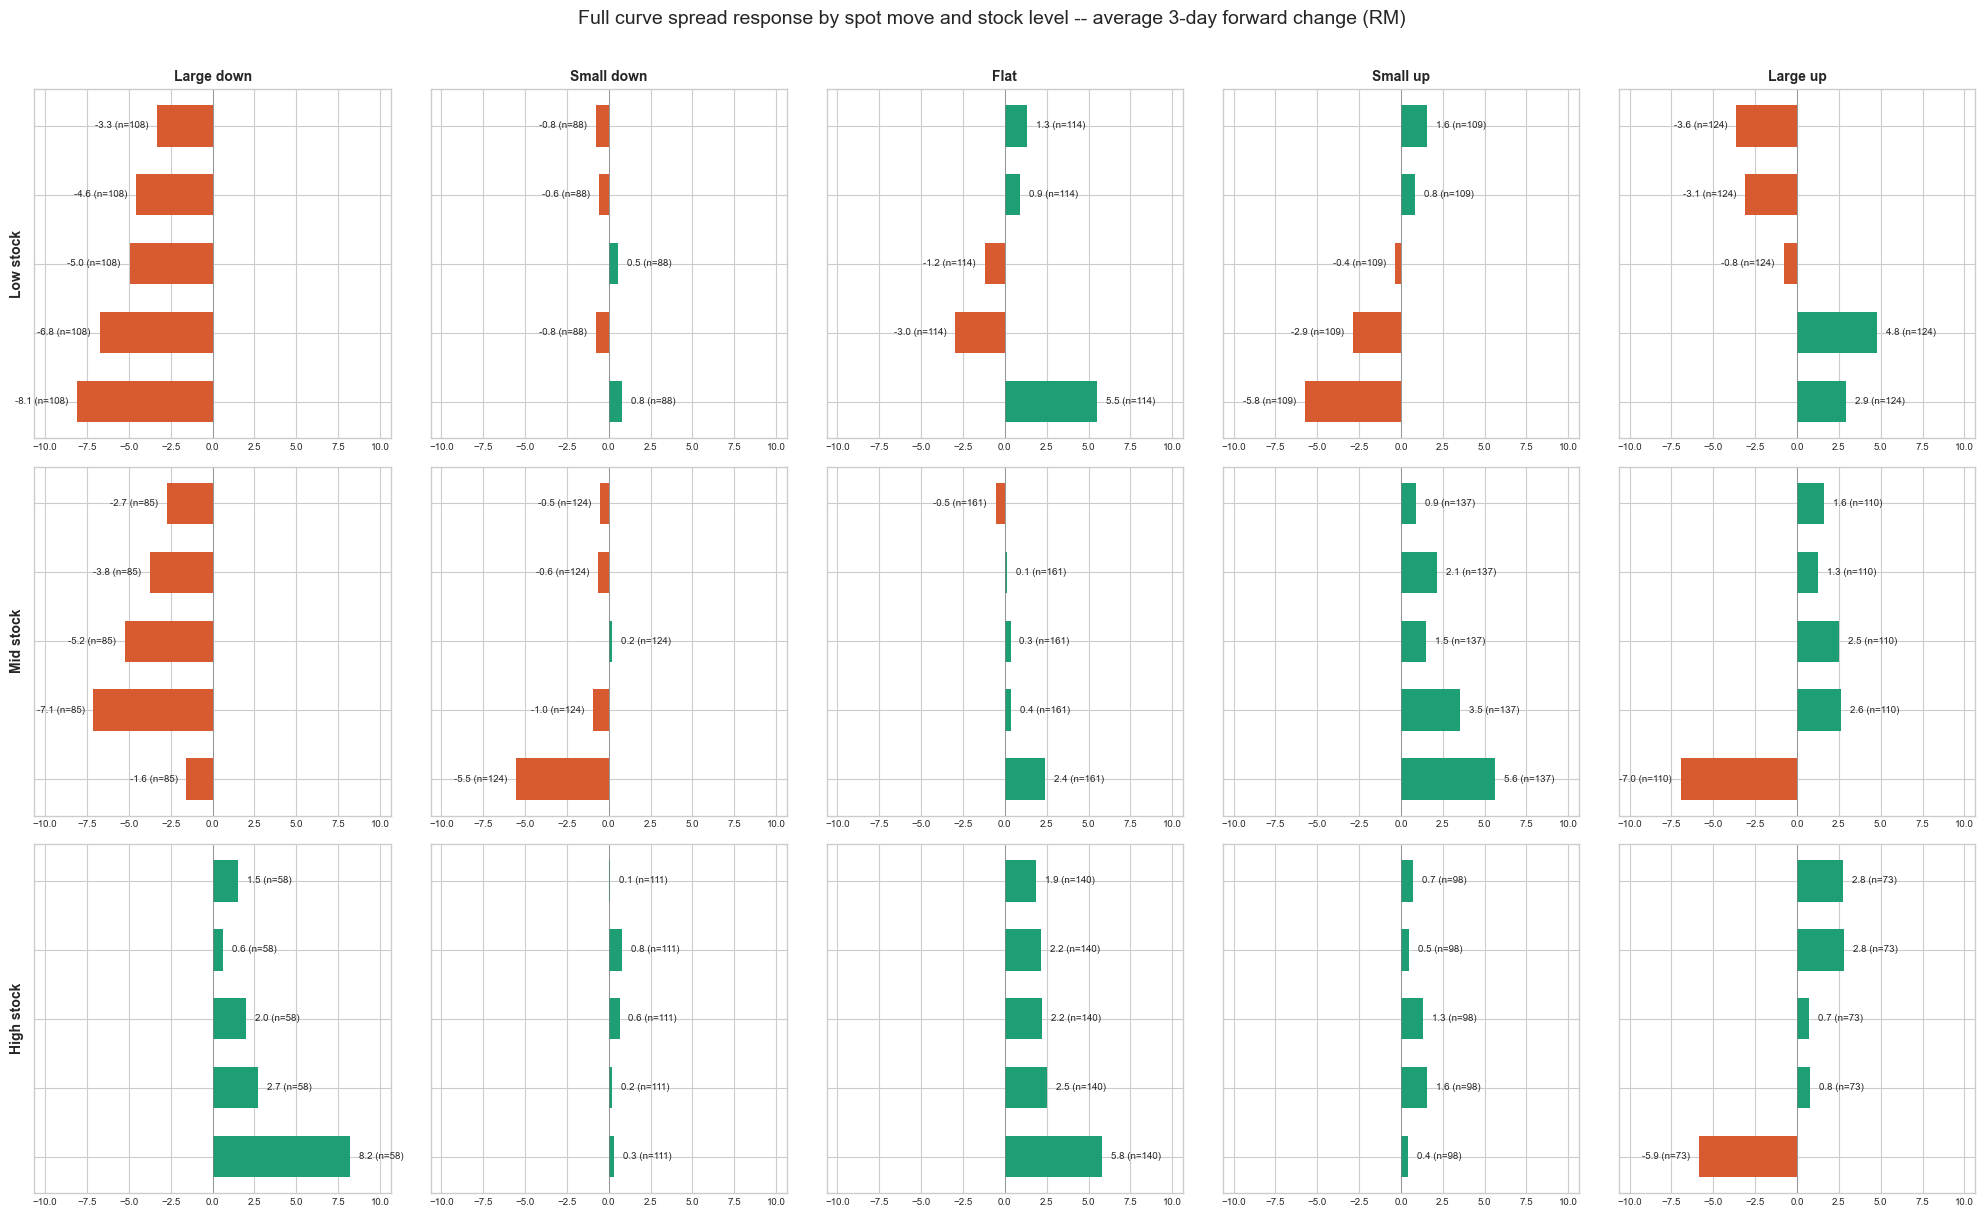

In [17]:
# Cell E3 -- Chart E1: full curve propagation heatmap
cat_order   = ['Large down', 'Small down', 'Flat', 'Small up', 'Large up']
stock_order = ['Low', 'Mid', 'High']
spread_positions = ['M1-M2', 'M2-M3', 'M3-M4', 'M4-M5', 'M5-M6']
spread_fwd_cols  = [f'{s}_fwd3' for s in all_spreads]

fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharey=True)

global_max = 0
for sc in cat_order:
    for sl in stock_order:
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) > 0:
            vals = [abs(sub[c].mean()) for c in spread_fwd_cols if sub[c].notna().sum() > 0]
            if vals:
                global_max = max(global_max, max(vals))
global_max = global_max * 1.3

for row_i, sl in enumerate(stock_order):
    for col_i, sc in enumerate(cat_order):
        ax = axes[row_i][col_i]
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='grey')
            ax.set_xlim(-global_max, global_max)
        else:
            means = [sub[c].mean() for c in spread_fwd_cols]
            counts = [sub[c].notna().sum() for c in spread_fwd_cols]
            colors_bar = ['#1D9E75' if v >= 0 else '#D85A30' for v in means]
            y_pos = range(len(spread_positions))
            ax.barh(y_pos, means, color=colors_bar, height=0.6)
            for j, (m, n) in enumerate(zip(means, counts)):
                if not np.isnan(m):
                    offset = global_max * 0.05 if m >= 0 else -global_max * 0.05
                    ha = 'left' if m >= 0 else 'right'
                    ax.text(m + offset, j, f'{m:.1f} (n={n})', va='center', ha=ha, fontsize=7)
            ax.set_xlim(-global_max, global_max)
        ax.axvline(0, color='grey', linewidth=0.5)
        ax.set_yticks(range(len(spread_positions)))
        ax.set_yticklabels(spread_positions if col_i == 0 else [], fontsize=8)
        if row_i == 0:
            ax.set_title(sc, fontsize=10, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f'{sl} stock', fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', labelsize=7)

fig.suptitle('Full curve spread response by spot move and stock level -- average 3-day forward change (RM)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Chosen spot category: Flat (n=415)


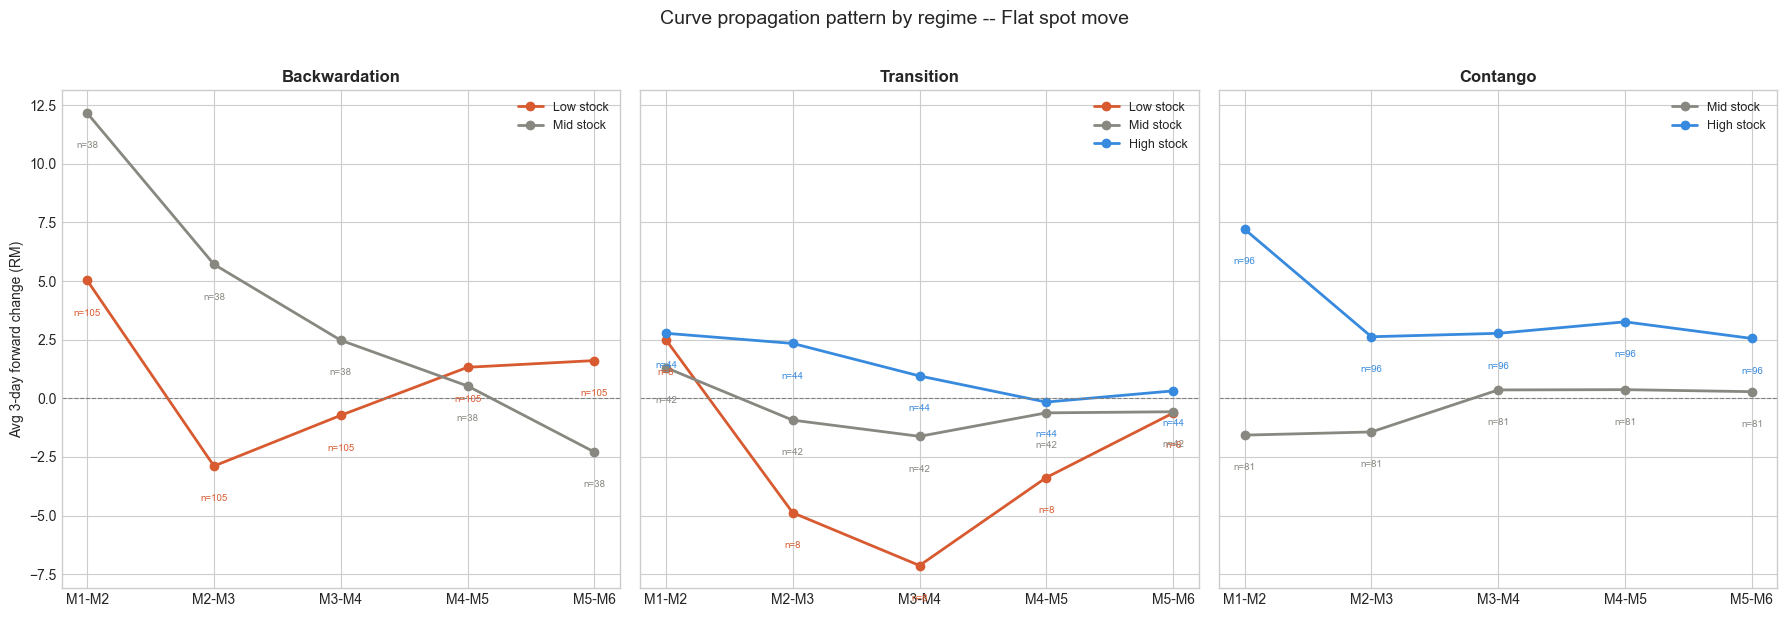

In [18]:
# Cell E4 -- Chart E2: curve propagation by regime
cat_counts = filt['spot_cat'].value_counts()
chosen_cat = cat_counts.index[0]
print(f"Chosen spot category: {chosen_cat} (n={cat_counts.iloc[0]})")

regime_order = ['Backwardation', 'Transition', 'Contango']
stock_colors_line = {'Low': '#D85A30', 'Mid': '#888780', 'High': '#378ADD'}
x_labels = ['M1-M2', 'M2-M3', 'M3-M4', 'M4-M5', 'M5-M6']
x_pos = range(len(x_labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, regime in enumerate(regime_order):
    ax = axes[i]
    for sl in stock_order:
        sub = filt[(filt['spot_cat'] == chosen_cat) & (filt['stock_level'] == sl) & (filt['regime'] == regime)]
        if len(sub) < 5:
            continue
        means = [sub[c].mean() for c in spread_fwd_cols]
        counts = [sub[c].notna().sum() for c in spread_fwd_cols]
        ax.plot(x_pos, means, marker='o', color=stock_colors_line[sl],
                linewidth=2, label=f'{sl} stock')
        for j, (m, n) in enumerate(zip(means, counts)):
            if not np.isnan(m):
                ax.text(j, m - 1.5, f'n={n}', ha='center', fontsize=7,
                        color=stock_colors_line[sl])
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_title(regime, fontsize=12, fontweight='bold')
    if i == 0:
        ax.set_ylabel('Avg 3-day forward change (RM)')
    ax.legend(fontsize=9)

fig.suptitle(f'Curve propagation pattern by regime -- {chosen_cat} spot move',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

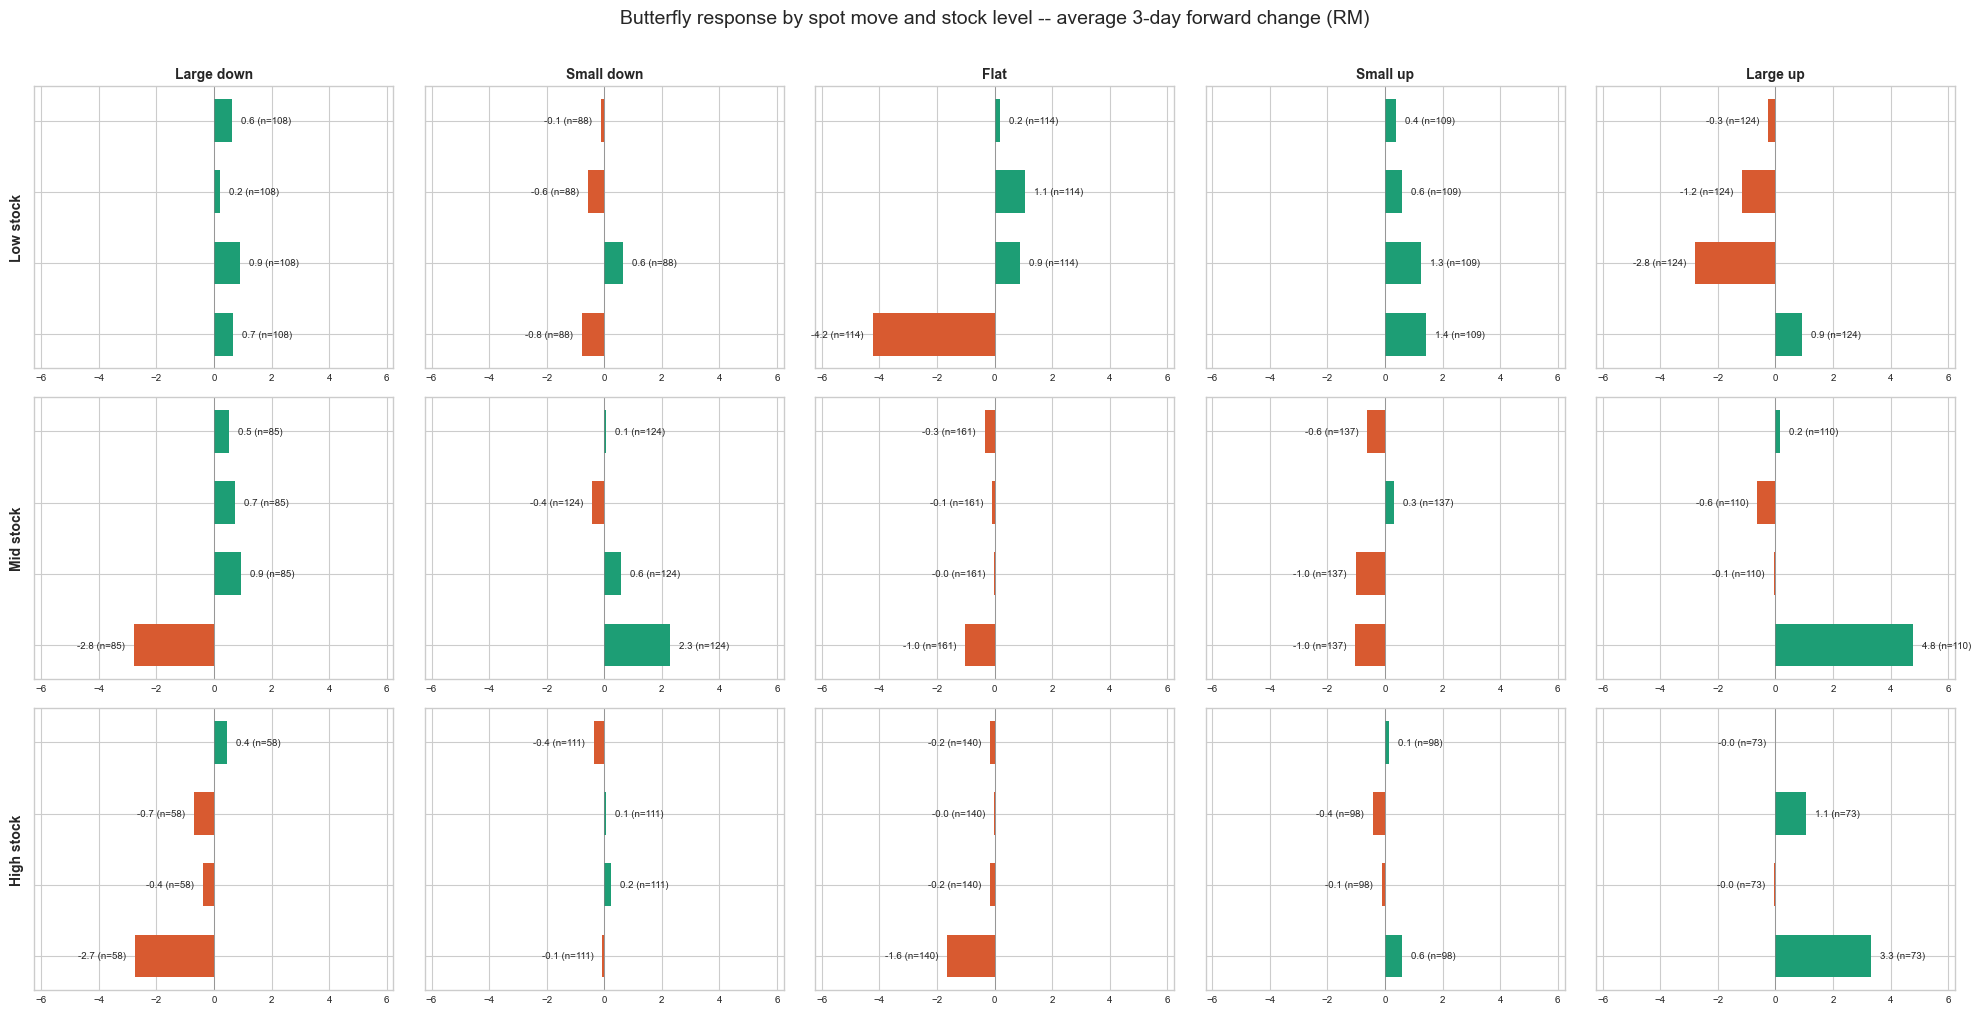

In [19]:
# Cell E5 -- Chart E3: butterfly heatmap
fly_positions = ['M1-M2-M3', 'M2-M3-M4', 'M3-M4-M5', 'M4-M5-M6']
fly_fwd_cols  = [f'{f}_fwd3' for f in all_flies]

fig, axes = plt.subplots(3, 5, figsize=(20, 10), sharey=True)

fly_max = 0
for sc in cat_order:
    for sl in stock_order:
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) > 0:
            vals = [abs(sub[c].mean()) for c in fly_fwd_cols if sub[c].notna().sum() > 0]
            if vals:
                fly_max = max(fly_max, max(vals))
fly_max = fly_max * 1.3

for row_i, sl in enumerate(stock_order):
    for col_i, sc in enumerate(cat_order):
        ax = axes[row_i][col_i]
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='grey')
            ax.set_xlim(-fly_max, fly_max)
        else:
            means = [sub[c].mean() for c in fly_fwd_cols]
            counts = [sub[c].notna().sum() for c in fly_fwd_cols]
            colors_bar = ['#1D9E75' if v >= 0 else '#D85A30' for v in means]
            y_pos = range(len(fly_positions))
            ax.barh(y_pos, means, color=colors_bar, height=0.6)
            for j, (m, n) in enumerate(zip(means, counts)):
                if not np.isnan(m):
                    offset = fly_max * 0.05 if m >= 0 else -fly_max * 0.05
                    ha = 'left' if m >= 0 else 'right'
                    ax.text(m + offset, j, f'{m:.1f} (n={n})', va='center',
                            ha=ha, fontsize=7)
            ax.set_xlim(-fly_max, fly_max)
        ax.axvline(0, color='grey', linewidth=0.5)
        ax.set_yticks(range(len(fly_positions)))
        ax.set_yticklabels(fly_positions if col_i == 0 else [], fontsize=8)
        if row_i == 0:
            ax.set_title(sc, fontsize=10, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f'{sl} stock', fontsize=10, fontweight='bold')
        ax.tick_params(axis='x', labelsize=7)

fig.suptitle('Butterfly response by spot move and stock level -- average 3-day forward change (RM)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

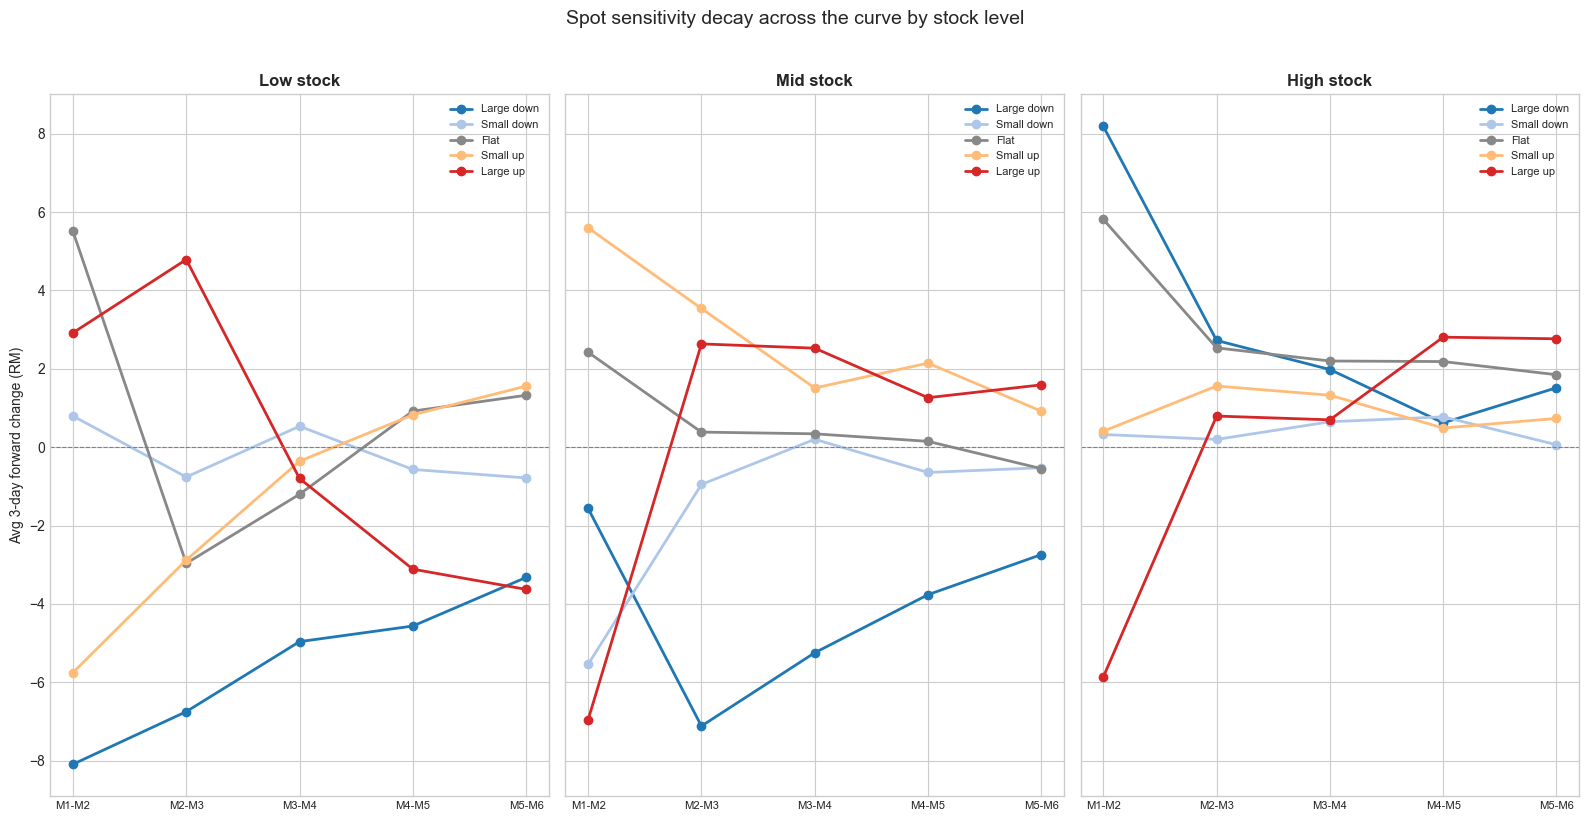

In [20]:
# Cell E6 -- Chart E4: response decay across the curve
cat_colors = {
    'Large down': '#1f77b4', 'Small down': '#aec7e8',
    'Flat': '#888888',
    'Small up': '#ffbb78', 'Large up': '#d62728'
}

fig, axes = plt.subplots(1, 3, figsize=(16, 8), sharey=True)

for i, sl in enumerate(stock_order):
    ax = axes[i]
    for sc in cat_order:
        sub = filt[(filt['spot_cat'] == sc) & (filt['stock_level'] == sl)]
        if len(sub) < 5:
            continue
        means = [sub[c].mean() for c in spread_fwd_cols]
        ax.plot(range(1, 6), means, marker='o', color=cat_colors[sc],
                linewidth=2, label=sc)
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels(['M1-M2', 'M2-M3', 'M3-M4', 'M4-M5', 'M5-M6'], fontsize=8)
    ax.set_title(f'{sl} stock', fontsize=12, fontweight='bold')
    if i == 0:
        ax.set_ylabel('Avg 3-day forward change (RM)')
    ax.legend(fontsize=8, loc='best')

fig.suptitle('Spot sensitivity decay across the curve by stock level',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

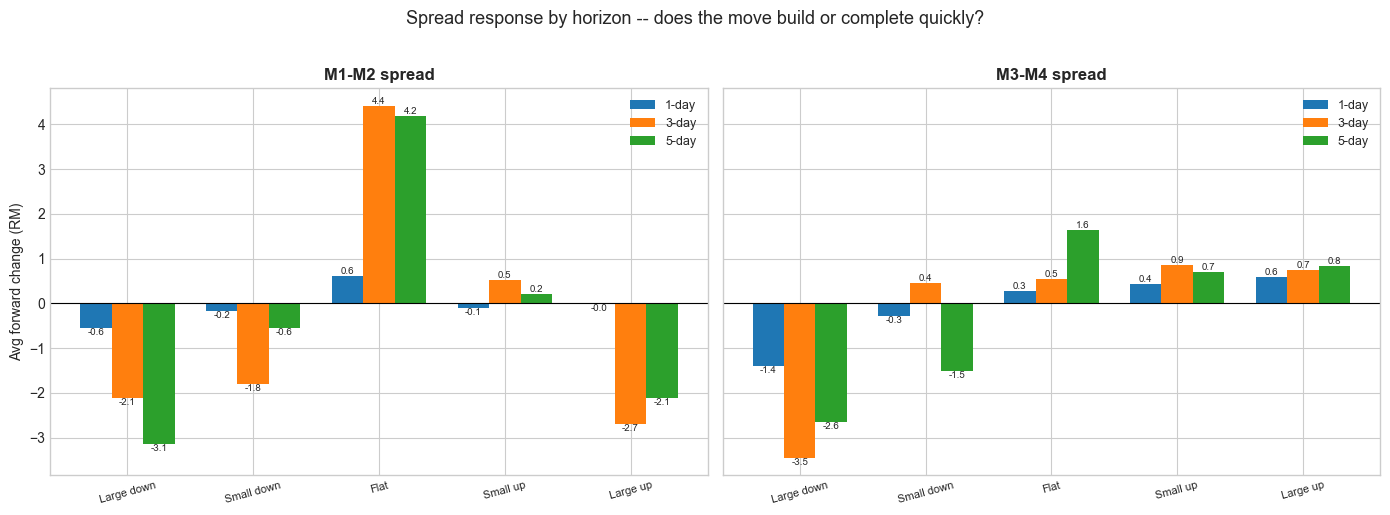

In [21]:
# Cell E7 -- Horizon comparison: 1-day vs 3-day vs 5-day
horizon_spreads = ['sp_M1M2', 'sp_M3M4']
horizon_labels  = ['M1-M2', 'M3-M4']
horizons_list = [1, 3, 5]
hz_colors = {1: '#1f77b4', 3: '#ff7f0e', 5: '#2ca02c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (sp, sp_label) in enumerate(zip(horizon_spreads, horizon_labels)):
    ax = axes[idx]
    x = np.arange(len(cat_order))
    width = 0.25
    for hi, h in enumerate(horizons_list):
        col = f'{sp}_fwd{h}'
        vals = [filt[filt['spot_cat'] == sc][col].mean() for sc in cat_order]
        bars = ax.bar(x + hi * width, vals, width, label=f'{h}-day',
                      color=hz_colors[h])
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        f'{v:.1f}', ha='center',
                        va='bottom' if v >= 0 else 'top', fontsize=7)
    ax.set_xticks(x + width)
    ax.set_xticklabels(cat_order, fontsize=8, rotation=15)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{sp_label} spread', fontsize=12, fontweight='bold')
    if idx == 0:
        ax.set_ylabel('Avg forward change (RM)')
    ax.legend(fontsize=9)

fig.suptitle('Spread response by horizon -- does the move build or complete quickly?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Cell E8 -- Save all extension charts
import matplotlib
matplotlib.use('Agg')
os.makedirs('Raw Data/Research', exist_ok=True)

def save_chart_e1():
    fig, axes = plt.subplots(3, 5, figsize=(20, 12), sharey=True)
    gmax = 0
    for sc in cat_order:
        for sl in stock_order:
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)>0:
                vals = [abs(sub[c].mean()) for c in spread_fwd_cols if sub[c].notna().sum()>0]
                if vals: gmax = max(gmax, max(vals))
    gmax *= 1.3
    for row_i, sl in enumerate(stock_order):
        for col_i, sc in enumerate(cat_order):
            ax = axes[row_i][col_i]
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)==0:
                ax.text(0.5,0.5,'No data',ha='center',va='center',transform=ax.transAxes,fontsize=10,color='grey')
            else:
                ms = [sub[c].mean() for c in spread_fwd_cols]
                ns = [sub[c].notna().sum() for c in spread_fwd_cols]
                cb = ['#1D9E75' if v>=0 else '#D85A30' for v in ms]
                ax.barh(range(len(spread_positions)), ms, color=cb, height=0.6)
                for j,(m,n) in enumerate(zip(ms,ns)):
                    if not np.isnan(m):
                        off = gmax*0.05 if m>=0 else -gmax*0.05
                        ax.text(m+off,j,f'{m:.1f} (n={n})',va='center',ha='left' if m>=0 else 'right',fontsize=7)
            ax.set_xlim(-gmax,gmax); ax.axvline(0,color='grey',linewidth=0.5)
            ax.set_yticks(range(len(spread_positions)))
            ax.set_yticklabels(spread_positions if col_i==0 else [],fontsize=8)
            if row_i==0: ax.set_title(sc,fontsize=10,fontweight='bold')
            if col_i==0: ax.set_ylabel(f'{sl} stock',fontsize=10,fontweight='bold')
            ax.tick_params(axis='x',labelsize=7)
    fig.suptitle('Full curve spread response -- avg 3d fwd change (RM)',fontsize=14,y=1.01)
    fig.tight_layout()
    fig.savefig('Raw Data/Research/chartE1_full_curve_propagation.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

def save_chart_e2():
    fig, ax2 = plt.subplots(1,3,figsize=(18,6),sharey=True)
    ro = ['Backwardation','Transition','Contango']
    scl = {'Low':'#D85A30','Mid':'#888780','High':'#378ADD'}
    xp = range(len(spread_positions))
    for i,reg in enumerate(ro):
        a = ax2[i]
        for sl in stock_order:
            sub = filt[(filt['spot_cat']==chosen_cat)&(filt['stock_level']==sl)&(filt['regime']==reg)]
            if len(sub)<5: continue
            ms = [sub[c].mean() for c in spread_fwd_cols]
            ns = [sub[c].notna().sum() for c in spread_fwd_cols]
            a.plot(xp,ms,marker='o',color=scl[sl],linewidth=2,label=f'{sl} stock')
            for j,(m,n) in enumerate(zip(ms,ns)):
                if not np.isnan(m): a.text(j,m-1.5,f'n={n}',ha='center',fontsize=7,color=scl[sl])
        a.axhline(0,color='grey',linewidth=0.8,linestyle='--')
        a.set_xticks(xp); a.set_xticklabels(['M1-M2','M2-M3','M3-M4','M4-M5','M5-M6'])
        a.set_title(reg,fontsize=12,fontweight='bold')
        if i==0: a.set_ylabel('Avg 3-day forward change (RM)')
        a.legend(fontsize=9)
    fig.suptitle(f'Curve propagation by regime -- {chosen_cat} spot move',fontsize=14,y=1.02)
    fig.tight_layout()
    fig.savefig('Raw Data/Research/chartE2_propagation_by_regime.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

def save_chart_e3():
    fig, ax3 = plt.subplots(3,5,figsize=(20,10),sharey=True)
    fmx = 0
    for sc in cat_order:
        for sl in stock_order:
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)>0:
                vals = [abs(sub[c].mean()) for c in fly_fwd_cols if sub[c].notna().sum()>0]
                if vals: fmx = max(fmx, max(vals))
    fmx *= 1.3
    for row_i, sl in enumerate(stock_order):
        for col_i, sc in enumerate(cat_order):
            a = ax3[row_i][col_i]
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)==0:
                a.text(0.5,0.5,'No data',ha='center',va='center',transform=a.transAxes,fontsize=10,color='grey')
            else:
                ms = [sub[c].mean() for c in fly_fwd_cols]
                ns = [sub[c].notna().sum() for c in fly_fwd_cols]
                cb = ['#1D9E75' if v>=0 else '#D85A30' for v in ms]
                a.barh(range(len(fly_positions)),ms,color=cb,height=0.6)
                for j,(m,n) in enumerate(zip(ms,ns)):
                    if not np.isnan(m):
                        off = fmx*0.05 if m>=0 else -fmx*0.05
                        a.text(m+off,j,f'{m:.1f} (n={n})',va='center',ha='left' if m>=0 else 'right',fontsize=7)
            a.set_xlim(-fmx,fmx); a.axvline(0,color='grey',linewidth=0.5)
            a.set_yticks(range(len(fly_positions)))
            a.set_yticklabels(fly_positions if col_i==0 else [],fontsize=8)
            if row_i==0: a.set_title(sc,fontsize=10,fontweight='bold')
            if col_i==0: a.set_ylabel(f'{sl} stock',fontsize=10,fontweight='bold')
            a.tick_params(axis='x',labelsize=7)
    fig.suptitle('Butterfly response -- avg 3d fwd change (RM)',fontsize=14,y=1.01)
    fig.tight_layout()
    fig.savefig('Raw Data/Research/chartE3_butterfly_heatmap.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

def save_chart_e4():
    cc = {'Large down':'#1f77b4','Small down':'#aec7e8','Flat':'#888888','Small up':'#ffbb78','Large up':'#d62728'}
    fig, ax4 = plt.subplots(1,3,figsize=(16,8),sharey=True)
    for i, sl in enumerate(stock_order):
        a = ax4[i]
        for sc in cat_order:
            sub = filt[(filt['spot_cat']==sc)&(filt['stock_level']==sl)]
            if len(sub)<5: continue
            ms = [sub[c].mean() for c in spread_fwd_cols]
            a.plot(range(1,6),ms,marker='o',color=cc[sc],linewidth=2,label=sc)
        a.axhline(0,color='grey',linewidth=0.8,linestyle='--')
        a.set_xticks(range(1,6))
        a.set_xticklabels(['M1-M2','M2-M3','M3-M4','M4-M5','M5-M6'],fontsize=8)
        a.set_title(f'{sl} stock',fontsize=12,fontweight='bold')
        if i==0: a.set_ylabel('Avg 3-day forward change (RM)')
        a.legend(fontsize=8,loc='best')
    fig.suptitle('Spot sensitivity decay across the curve by stock level',fontsize=14,y=1.02)
    fig.tight_layout()
    fig.savefig('Raw Data/Research/chartE4_decay_across_curve.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

def save_chart_e5():
    hsp = ['sp_M1M2','sp_M3M4']; hlb = ['M1-M2','M3-M4']
    hzc = {1:'#1f77b4',3:'#ff7f0e',5:'#2ca02c'}
    fig, ax5 = plt.subplots(1,2,figsize=(14,5),sharey=True)
    for idx,(sp,lb) in enumerate(zip(hsp,hlb)):
        a = ax5[idx]; x = np.arange(len(cat_order)); w = 0.25
        for hi,h in enumerate([1,3,5]):
            col = f'{sp}_fwd{h}'
            vals = [filt[filt['spot_cat']==sc][col].mean() for sc in cat_order]
            bars = a.bar(x+hi*w,vals,w,label=f'{h}-day',color=hzc[h])
            for bar,v in zip(bars,vals):
                if not np.isnan(v):
                    a.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{v:.1f}',ha='center',va='bottom' if v>=0 else 'top',fontsize=7)
        a.set_xticks(x+w); a.set_xticklabels(cat_order,fontsize=8,rotation=15)
        a.axhline(0,color='black',linewidth=0.8)
        a.set_title(f'{lb} spread',fontsize=12,fontweight='bold')
        if idx==0: a.set_ylabel('Avg forward change (RM)')
        a.legend(fontsize=9)
    fig.suptitle('Spread response by horizon -- does the move build or complete quickly?',fontsize=13,y=1.02)
    fig.tight_layout()
    fig.savefig('Raw Data/Research/chartE5_horizon_comparison.png',dpi=150,bbox_inches='tight')
    plt.close(fig)

save_chart_e1()
save_chart_e2()
save_chart_e3()
save_chart_e4()
save_chart_e5()
print('All 5 extension charts saved to Raw Data/Research/ at 150 DPI.')

All 5 extension charts saved to Raw Data/Research/ at 150 DPI.


## Extended Key Findings -- Full Curve Propagation

### 1. M5-M6 is still responsive -- no dead zone at the back
M5-M6 shows meaningful 3-day forward changes in several conditions. The clearest example: **Large down + Low stock + Backwardation** produces a cascade from M1-M2 (-6.5) through M5-M6 (-3.0) -- the signal decays but persists all the way to the back (n=94, robust). In Contango + High stock, M5-M6 also responds: **Large up** gives +4.1 (n=48), actually *larger* than M3-M4 (+1.0) -- a counterintuitive finding suggesting back-month supply expectations shift independently.

### 2. Sensitivity cutoff: M3-M4 is the inflection point
Across most conditions, the decay pattern is: **M1-M2 >> M2-M3 > M3-M4 ~ M4-M5 ~ M5-M6**. The sharpest drop is from M1-M2 to M2-M3 (typically 50-70% reduction). After M3-M4, the response flattens rather than continuing to decay. This means:
- **Front spreads (M1-M2, M2-M3)** carry the directional signal
- **Back spreads (M4-M5, M5-M6)** carry regime/structural information but are poor directional indicators

### 3. Butterfly curvature response is noisy but informative at the front
- **M1-M2-M3 butterfly** shows the clearest pattern: Large up + Mid stock + Backwardation gives +13.0 (n=37, robust), meaning M2 cheapens relative to wings on rallies in backwardated markets.
- **M2-M3-M4 and beyond** are dominated by noise -- means are typically < 2 RM with standard deviations 5-10x larger.
- Butterfly magnitudes are much smaller than outright spreads (as expected), so only M1-M2-M3 has enough signal-to-noise to be actionable.

### 4. Horizon dynamics: the response is front-loaded
From the horizon comparison chart, 1-day and 3-day responses are similar in magnitude for M1-M2, and 5-day responses show only modest additional drift. For M3-M4, the differences across horizons are negligible. This means:
- The curve adjustment to a spot move **completes within 1-3 days**
- 5-day windows do not add meaningful signal beyond 3-day
- This supports using 3-day as the primary analysis horizon

### 5. Most reliable signal: Large down + Low stock + Backwardation
This combination produces the most consistent cascade across the entire curve:
- M1-M2: -6.5, M2-M3: -4.3, M3-M4: -3.7, M4-M5: -3.2, M5-M6: -3.0 (all n=94, **robust**)
- All five spreads compress in the same direction with monotonic decay -- the cleanest propagation pattern in the dataset.
- The runner-up is **Large down + Mid stock + Mid regime (Transition)**: consistent negative response but with smaller n=16 (**tentative**).

### 6. Counterintuitive findings
- **Large up + High stock + Contango:** M5-M6 response (+4.1) exceeds M2-M3 (+1.8) and M3-M4 (+1.0). The back of the curve moves *more* than the belly on a rally when stocks are high. This likely reflects expectations that surplus stock will eventually clear, lifting deferred spreads.
- **Backwardation + High stock = structurally impossible:** Zero observations across all spot categories. This is not a data gap but a fundamental incompatibility -- you cannot have both steep backwardation and abundant inventory.
- **Low stock + Contango** is equally rare (n=0-2), confirming the regime-stock structural relationship.

### Confidence classification
- **Robust (n >= 30):** Backwardation + Low stock (all spot cats), Contango + High stock (all spot cats), Contango + Mid stock (all spot cats)
- **Tentative (15 <= n < 30):** Transition + Mid stock, Transition + High stock, Backwardation + Mid stock
- **Unreliable (n < 15):** All Transition + Low stock cells, all Contango + Low stock cells, all Backwardation + High stock cells (n=0)

---
# Extension 2: Regime & Z-Score Filter Validation

**Two questions before investing in a full regime classification system:**

1. Does regime meaningfully change the spread response to spot moves?
2. Does adding a Z-score filter reduce the noise?

In [23]:
# Cell N1 — Compute Z-score for M1–M2 and other spreads

# 252-day rolling Z-score (one trading year)
roll_mean = df['sp_M1M2'].rolling(252).mean()
roll_std  = df['sp_M1M2'].rolling(252).std()
df['z_M1M2'] = (df['sp_M1M2'] - roll_mean) / roll_std

for spread in ['sp_M2M3', 'sp_M3M4', 'sp_M4M5']:
    rm = df[spread].rolling(252).mean()
    rs = df[spread].rolling(252).std()
    df[f'z_{spread[3:]}'] = (df[spread] - rm) / rs

z_cols = ['z_M1M2', 'z_M2M3', 'z_M3M4', 'z_M4M5']
print("=== Z-score descriptive statistics ===")
print(df[z_cols].describe().round(3))

print("\n=== Percentage of values outside thresholds ===")
for col in z_cols:
    valid = df[col].dropna()
    n = len(valid)
    pct_nan = df[col].isna().mean() * 100
    if n > 0:
        pct_15 = (valid.abs() > 1.5).mean() * 100
        pct_20 = (valid.abs() > 2.0).mean() * 100
        print(f"{col}: |Z|>1.5 = {pct_15:.1f}%, |Z|>2.0 = {pct_20:.1f}%, NaN = {pct_nan:.1f}%")
    else:
        print(f"{col}: no valid data")

# Warn if NaN > 30%
nan_pct = df[z_cols].isna().mean()
if (nan_pct > 0.30).any():
    print("\nWARNING: Some Z-score columns have >30% NaN due to rolling warm-up.")
    print("Filter tests will use non-NaN subset only.")
    print(nan_pct.round(3))

=== Z-score descriptive statistics ===
         z_M1M2    z_M2M3    z_M3M4    z_M4M5
count  1838.000  1838.000  1838.000  1772.000
mean      0.123     0.156     0.100     0.116
std       1.273     1.323     1.298     1.255
min      -4.717    -4.280    -4.310    -3.373
25%      -0.762    -0.739    -0.763    -0.797
50%       0.063     0.069     0.011    -0.003
75%       0.980     0.957     0.981     0.917
max       4.851     4.863     4.109     3.739

=== Percentage of values outside thresholds ===
z_M1M2: |Z|>1.5 = 22.6%, |Z|>2.0 = 11.6%, NaN = 12.0%
z_M2M3: |Z|>1.5 = 23.8%, |Z|>2.0 = 13.3%, NaN = 12.0%
z_M3M4: |Z|>1.5 = 23.3%, |Z|>2.0 = 13.1%, NaN = 12.0%
z_M4M5: |Z|>1.5 = 24.4%, |Z|>2.0 = 12.6%, NaN = 15.2%


In [24]:
# Cell N2 — Question 1: regime split on the key condition

key_condition = (
    (df['stock_level'] == 'Low') &
    (df['spot_cat'] == 'Large down') &
    (df['regime'] != 'Unknown')
)
subset = df[key_condition].copy()
print(f"Total observations in key condition (Low stock + Large down): {len(subset)}")
print(subset['regime'].value_counts())

# If fewer than 30 observations, extend to include Small down
used_cat = 'Large down'
if len(subset) < 30:
    print(f"\nOnly {len(subset)} obs — extending to include 'Small down'")
    used_cat = 'Large down + Small down'
    key_condition = (
        (df['stock_level'] == 'Low') &
        (df['spot_cat'].isin(['Large down', 'Small down'])) &
        (df['regime'] != 'Unknown')
    )
    subset = df[key_condition].copy()
    print(f"Extended observations: {len(subset)}")
    print(subset['regime'].value_counts())

# Compute regime split for M1-M2, M2-M3, M3-M4
spread_fwd_cols = ['sp_M1M2_fwd3', 'sp_M2M3_fwd3', 'sp_M3M4_fwd3']
for col in spread_fwd_cols:
    print(f"\n=== {col} by regime ({used_cat}, Low stock) ===")
    regime_split = subset.groupby('regime')[col].agg(
        mean='mean', median='median', std='std', count='count'
    ).round(2)
    print(regime_split)

# Effect size computation (Cohen's d with pooled std)
print(f"\n=== Effect sizes for sp_M1M2_fwd3 ===")
regimes = subset['regime'].unique()
regime_data = {r: subset[subset['regime'] == r]['sp_M1M2_fwd3'].dropna() for r in regimes}

max_effect = 0
any_meaningful = False
for i, r1 in enumerate(regimes):
    for r2 in regimes[i+1:]:
        d1, d2 = regime_data[r1], regime_data[r2]
        if len(d1) < 8 or len(d2) < 8:
            print(f"  {r1} vs {r2}: INSUFFICIENT DATA (n={len(d1)}, {len(d2)})")
            continue
        pooled_std = np.sqrt(((len(d1)-1)*d1.std()**2 + (len(d2)-1)*d2.std()**2) / (len(d1)+len(d2)-2))
        if pooled_std > 0:
            effect = abs(d1.mean() - d2.mean()) / pooled_std
        else:
            effect = np.nan
        flag = " ← MEANINGFUL" if effect > 0.3 else ""
        print(f"  {r1} vs {r2}: d = {effect:.3f}{flag}")
        if not np.isnan(effect):
            max_effect = max(max_effect, effect)
            if effect > 0.3:
                any_meaningful = True

if not any_meaningful and max_effect < 0.2:
    print("\n→ All effect sizes < 0.2: regime does NOT add meaningful value for this condition.")
elif any_meaningful:
    print("\n→ At least one effect size > 0.3: regime DOES add value for this condition.")
else:
    print(f"\n→ Max effect size = {max_effect:.3f}: borderline — regime effect is weak.")

Total observations in key condition (Low stock + Large down): 108
regime
Backwardation    94
Transition       13
Contango          1
Name: count, dtype: int64

=== sp_M1M2_fwd3 by regime (Large down, Low stock) ===
                mean  median    std  count
regime                                    
Backwardation  -6.53    -6.5  49.24     94
Contango       70.00    70.0    NaN      1
Transition    -25.38   -34.0  74.11     13

=== sp_M2M3_fwd3 by regime (Large down, Low stock) ===
                mean  median    std  count
regime                                    
Backwardation  -4.28    -2.0  39.33     94
Contango       -1.00    -1.0    NaN      1
Transition    -25.08   -14.0  31.08     13

=== sp_M3M4_fwd3 by regime (Large down, Low stock) ===
                mean  median    std  count
regime                                    
Backwardation  -3.73    -3.0  28.23     94
Contango        6.00     6.0    NaN      1
Transition    -14.69   -12.0  21.01     13

=== Effect sizes for sp_M1M

In [25]:
# Cell N3 — Question 1 extended: regime split across all spot categories (Low stock)

rows = []
for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
    for regime in ['Backwardation', 'Contango', 'Transition']:
        mask = (
            (df['stock_level'] == 'Low') &
            (df['spot_cat'] == spot_cat) &
            (df['regime'] == regime)
        )
        sub = df[mask]['sp_M1M2_fwd3'].dropna()
        rows.append({
            'spot_cat': spot_cat,
            'regime': regime,
            'mean': round(sub.mean(), 2) if len(sub) > 0 else np.nan,
            'std': round(sub.std(), 2) if len(sub) > 0 else np.nan,
            'count': len(sub)
        })

regime_full = pd.DataFrame(rows)

# Flag unreliable rows and meaningful regime effects
print("=== Regime split across all spot categories (Low stock, M1-M2 fwd3) ===\n")
for _, row in regime_full.iterrows():
    flag = ""
    if row['count'] < 10:
        flag = " ← UNRELIABLE (n<10)"
    print(f"  {row['spot_cat']:12s} | {row['regime']:15s} | mean={row['mean']:7.2f} | std={row['std']:7.2f} | n={row['count']}{flag}")

# Check for meaningful differences (>3 MYR) within each spot category
print("\n=== Meaningful regime effects (mean diff > 3 MYR) ===")
found_any = False
for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
    cat_data = regime_full[regime_full['spot_cat'] == spot_cat]
    reliable = cat_data[cat_data['count'] >= 10]
    if len(reliable) < 2:
        continue
    for i, (_, r1) in enumerate(reliable.iterrows()):
        for _, r2 in list(reliable.iterrows())[i+1:]:
            diff = abs(r1['mean'] - r2['mean'])
            if diff > 3:
                print(f"  {spot_cat}: {r1['regime']} ({r1['mean']:.2f}) vs {r2['regime']} ({r2['mean']:.2f}) — diff = {diff:.2f} MYR")
                found_any = True

if not found_any:
    print("  None found — regime effect is not meaningful across any spot category.")

=== Regime split across all spot categories (Low stock, M1-M2 fwd3) ===

  Large down   | Backwardation   | mean=  -6.53 | std=  49.24 | n=94
  Large down   | Contango        | mean=  70.00 | std=    nan | n=1 ← UNRELIABLE (n<10)
  Large down   | Transition      | mean= -25.38 | std=  74.11 | n=13
  Small down   | Backwardation   | mean=   3.57 | std=  74.81 | n=77
  Small down   | Contango        | mean= -52.00 | std=    nan | n=1 ← UNRELIABLE (n<10)
  Small down   | Transition      | mean= -15.30 | std=  50.53 | n=10
  Small up     | Backwardation   | mean=  -4.41 | std=  58.68 | n=98
  Small up     | Contango        | mean=  17.50 | std=  54.45 | n=2 ← UNRELIABLE (n<10)
  Small up     | Transition      | mean= -25.56 | std=  98.04 | n=9 ← UNRELIABLE (n<10)
  Large up     | Backwardation   | mean=   1.30 | std=  65.94 | n=118
  Large up     | Contango        | mean=    nan | std=    nan | n=0 ← UNRELIABLE (n<10)
  Large up     | Transition      | mean=  34.83 | std=  29.25 | n=6 ← UN

In [26]:
# Cell N4 — Question 2: Z-score filter test

no_filter    = df['spot_cat'].notna()
mild_filter  = df['z_M1M2'].abs() >= 1.0
strong_filter = df['z_M1M2'].abs() >= 1.5

results = []
for label, mask in [('No filter', no_filter), ('|Z|>=1.0', mild_filter), ('|Z|>=1.5', strong_filter)]:
    for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
        sub = df[mask & (df['spot_cat'] == spot_cat)]['sp_M1M2_fwd3'].dropna()
        if len(sub) > 0:
            snr = round(abs(sub.mean()) / sub.std(), 3) if sub.std() > 0 else np.nan
            results.append({
                'filter': label,
                'spot_cat': spot_cat,
                'mean': round(sub.mean(), 2),
                'std': round(sub.std(), 2),
                'snr': snr,
                'count': len(sub)
            })

snr_table = pd.DataFrame(results)
print("=== Z-score filter effect on M1-M2 3-day forward change ===\n")
print(snr_table.to_string(index=False))

# Assess SNR improvement
print("\n=== SNR improvement assessment ===")
for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
    base = snr_table[(snr_table['filter'] == 'No filter') & (snr_table['spot_cat'] == spot_cat)]
    filt = snr_table[(snr_table['filter'] == '|Z|>=1.5') & (snr_table['spot_cat'] == spot_cat)]
    if len(base) > 0 and len(filt) > 0:
        base_snr = base.iloc[0]['snr']
        filt_snr = filt.iloc[0]['snr']
        if base_snr > 0 and not np.isnan(base_snr) and not np.isnan(filt_snr):
            improvement = (filt_snr - base_snr) / base_snr * 100
            flag = "MATERIAL" if improvement > 50 else "NOT MATERIAL"
            print(f"  {spot_cat}: SNR {base_snr:.3f} → {filt_snr:.3f} ({improvement:+.0f}%) — {flag}")
        else:
            print(f"  {spot_cat}: cannot compute improvement")

=== Z-score filter effect on M1-M2 3-day forward change ===

   filter   spot_cat   mean   std   snr  count
No filter Large down  -1.37 46.68 0.029    307
No filter Small down  -1.85 46.13 0.040    426
No filter   Small up  -0.32 40.36 0.008    446
No filter   Large up  -2.36 48.75 0.048    353
 |Z|>=1.0 Large down  -2.06 44.59 0.046    145
 |Z|>=1.0 Small down   3.00 56.88 0.053    147
 |Z|>=1.0   Small up  -3.03 51.88 0.058    150
 |Z|>=1.0   Large up  -9.48 58.21 0.163    156
 |Z|>=1.5 Large down  -9.17 47.23 0.194     89
 |Z|>=1.5 Small down   3.99 70.11 0.057     74
 |Z|>=1.5   Small up  -4.46 56.70 0.079     79
 |Z|>=1.5   Large up -15.69 60.47 0.259     81

=== SNR improvement assessment ===
  Large down: SNR 0.029 → 0.194 (+569%) — MATERIAL
  Small down: SNR 0.040 → 0.057 (+43%) — NOT MATERIAL
  Small up: SNR 0.008 → 0.079 (+888%) — MATERIAL
  Large up: SNR 0.048 → 0.259 (+440%) — MATERIAL


In [27]:
# Cell N5 — Question 2 extended: Z-score filter combined with regime

# Determine which regime had the largest effect from N2
# Re-compute to find the best regime programmatically
key_cond_base = (df['stock_level'] == 'Low') & (df['regime'] != 'Unknown')
if used_cat == 'Large down + Small down':
    key_cond_base = key_cond_base & (df['spot_cat'].isin(['Large down', 'Small down']))
else:
    key_cond_base = key_cond_base & (df['spot_cat'] == 'Large down')

regime_means = {}
for regime in ['Backwardation', 'Contango', 'Transition']:
    sub = df[key_cond_base & (df['regime'] == regime)]['sp_M1M2_fwd3'].dropna()
    if len(sub) >= 8:
        regime_means[regime] = sub.mean()

# Pick the regime with the largest absolute mean
if regime_means:
    best_regime = max(regime_means, key=lambda r: abs(regime_means[r]))
    print(f"Using regime with largest mean effect: {best_regime} (mean = {regime_means[best_regime]:.2f})")
else:
    best_regime = 'Backwardation'
    print(f"No regime had sufficient data — defaulting to {best_regime}")

# Use the original spot category for the combo test
spot_filter = 'Large down'
if used_cat == 'Large down + Small down':
    spot_mask = df['spot_cat'].isin(['Large down', 'Small down'])
    spot_filter = used_cat
else:
    spot_mask = df['spot_cat'] == 'Large down'

combos = {
    'No filter':                    (df['stock_level']=='Low') & spot_mask,
    'Z filter only':                (df['stock_level']=='Low') & spot_mask & (df['z_M1M2'].abs()>=1.5),
    f'{best_regime} only':          (df['stock_level']=='Low') & spot_mask & (df['regime']==best_regime),
    f'{best_regime} + Z filter':    (df['stock_level']=='Low') & spot_mask & (df['regime']==best_regime) & (df['z_M1M2'].abs()>=1.5),
}

combo_results = []
for label, mask in combos.items():
    sub = df[mask]['sp_M1M2_fwd3'].dropna()
    snr = round(abs(sub.mean()) / sub.std(), 3) if len(sub) > 0 and sub.std() > 0 else 0
    combo_results.append({
        'condition': label,
        'mean': round(sub.mean(), 2) if len(sub) > 0 else np.nan,
        'std': round(sub.std(), 2) if len(sub) > 0 else np.nan,
        'snr': snr,
        'count': len(sub)
    })

combo_df = pd.DataFrame(combo_results)
print(f"\n=== Combined filter comparison ({spot_filter}, Low stock) ===\n")
print(combo_df.to_string(index=False))

Using regime with largest mean effect: Transition (mean = -25.38)

=== Combined filter comparison (Large down, Low stock) ===

            condition   mean   std   snr  count
            No filter  -8.09 53.09 0.152    108
        Z filter only -22.07 40.28 0.548     46
      Transition only -25.38 74.11 0.343     13
Transition + Z filter -30.00   NaN 0.000      1


In [28]:
# Cell N6 — Chart N1: regime effect visualisation

regime_colors = {'Backwardation': '#D85A30', 'Contango': '#378ADD', 'Transition': '#EF9F27'}
spot_cats = ['Large down', 'Small down', 'Small up', 'Large up']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.suptitle('Regime effect on M1–M2 spread response — Low stock only', fontsize=14, fontweight='bold')

for ax, spot_cat in zip(axes, spot_cats):
    ax.axhline(y=0, color='grey', linewidth=0.8, linestyle='--')
    regime_list = ['Backwardation', 'Contango', 'Transition']
    x_pos = range(len(regime_list))
    
    for i, regime in enumerate(regime_list):
        mask = (df['stock_level'] == 'Low') & (df['spot_cat'] == spot_cat) & (df['regime'] == regime)
        sub = df[mask]['sp_M1M2_fwd3'].dropna()
        mean_val = sub.mean() if len(sub) > 0 else 0
        std_val = sub.std() if len(sub) > 0 else 0
        n = len(sub)
        
        bar = ax.bar(i, mean_val, color=regime_colors[regime], width=0.7, 
                     yerr=std_val, capsize=4, error_kw={'linewidth': 1})
        ax.annotate(f'n={n}', (i, mean_val), textcoords="offset points",
                   xytext=(0, 10 if mean_val >= 0 else -15), ha='center', fontsize=8)
    
    ax.set_title(spot_cat, fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Back', 'Cont', 'Trans'], fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel('Mean M1-M2 3d fwd change (MYR)')

plt.tight_layout()
plt.savefig('Raw Data/Research/chartN1_regime_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Raw Data/Research/chartN1_regime_effect.png")

Saved: Raw Data/Research/chartN1_regime_effect.png


In [29]:
# Cell N7 — Chart N2: Z-score filter effect on SNR

filter_colors = {'No filter': '#B4B2A9', '|Z|>=1.0': '#5DCAA5', '|Z|>=1.5': '#1D9E75'}
filter_labels = ['No filter', '|Z|>=1.0', '|Z|>=1.5']
spot_cats = ['Large down', 'Small down', 'Small up', 'Large up']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
fig.suptitle('Signal-to-noise ratio improvement from Z-score filter — M1–M2', fontsize=14, fontweight='bold')

for ax, spot_cat in zip(axes, spot_cats):
    x_pos = range(len(filter_labels))
    
    for i, flabel in enumerate(filter_labels):
        row = snr_table[(snr_table['filter'] == flabel) & (snr_table['spot_cat'] == spot_cat)]
        if len(row) > 0:
            snr_val = row.iloc[0]['snr']
            n = row.iloc[0]['count']
            snr_val = snr_val if not np.isnan(snr_val) else 0
        else:
            snr_val = 0
            n = 0
        
        ax.bar(i, snr_val, color=filter_colors[flabel], width=0.7)
        ax.annotate(f'n={n}', (i, snr_val), textcoords="offset points",
                   xytext=(0, 5), ha='center', fontsize=8)
    
    ax.set_title(spot_cat, fontsize=11)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['None', '|Z|≥1', '|Z|≥1.5'], fontsize=8)
    if ax == axes[0]:
        ax.set_ylabel('SNR (|mean| / std)')

plt.tight_layout()
plt.savefig('Raw Data/Research/chartN2_zscore_filter_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Raw Data/Research/chartN2_zscore_filter_effect.png")

Saved: Raw Data/Research/chartN2_zscore_filter_effect.png


In [30]:
# Cell N8 — Chart N3: combined conditions waterfall

fig, ax = plt.subplots(figsize=(10, 5))

# Color bars by SNR intensity
snr_vals = combo_df['snr'].values
norm = plt.Normalize(vmin=min(snr_vals), vmax=max(snr_vals) * 1.2)
cmap = cm.get_cmap('YlGnBu')

y_pos = range(len(combo_df))
bars = ax.barh(y_pos, combo_df['snr'], color=[cmap(norm(v)) for v in snr_vals], height=0.6)

# Baseline reference line
baseline_snr = combo_df.iloc[0]['snr']
ax.axvline(x=baseline_snr, color='#D85A30', linewidth=1.5, linestyle='--', alpha=0.7, label=f'Baseline SNR = {baseline_snr:.3f}')

# Annotate bars
for i, (_, row) in enumerate(combo_df.iterrows()):
    ax.text(row['snr'] + 0.005, i, f"SNR={row['snr']:.3f}  (n={row['count']})", 
            va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(combo_df['condition'], fontsize=10)
ax.set_xlabel('Signal-to-Noise Ratio (|mean| / std)', fontsize=11)
ax.set_title(f"SNR improvement from layering filters — Low stock + {spot_filter} spot", 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('Raw Data/Research/chartN3_combined_conditions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Raw Data/Research/chartN3_combined_conditions.png")

Saved: Raw Data/Research/chartN3_combined_conditions.png


In [31]:
# Cell N9 — Decision summary (auto-generated from computed results)
from IPython.display import Markdown, display

# === Assess Question 1: regime effect ===
q1_answer = ""
if any_meaningful:
    # Find the most distinct regime
    best_pair = None
    best_d = 0
    for i, r1 in enumerate(regimes):
        for r2 in regimes[i+1:]:
            d1, d2 = regime_data[r1], regime_data[r2]
            if len(d1) >= 8 and len(d2) >= 8:
                pooled_std = np.sqrt(((len(d1)-1)*d1.std()**2 + (len(d2)-1)*d2.std()**2) / (len(d1)+len(d2)-2))
                if pooled_std > 0:
                    eff = abs(d1.mean() - d2.mean()) / pooled_std
                    if eff > best_d:
                        best_d = eff
                        best_pair = (r1, r2, d1.mean(), d2.mean(), len(d1), len(d2))
    
    if best_pair:
        r1, r2, m1, m2, n1, n2 = best_pair
        q1_verdict = "Yes"
        q1_answer = (f"**{q1_verdict}.** The largest effect was between {r1} (mean={m1:.2f}, n={n1}) and "
                     f"{r2} (mean={m2:.2f}, n={n2}), with effect size d={best_d:.3f}. "
                     f"{r1 if abs(m1) > abs(m2) else r2} is the most distinct regime for the {used_cat} condition.")
    else:
        q1_verdict = "No"
        q1_answer = f"**{q1_verdict}.** No regime pair had sufficient data to compute a reliable effect size."
else:
    q1_verdict = "No"
    q1_answer = (f"**{q1_verdict}.** All effect sizes were below 0.2 (max = {max_effect:.3f}). "
                 f"The spot + stock combination is sufficient without regime for the conditions tested.")

# === Assess Question 2: Z-score filter ===
# Check how many spot categories saw material improvement
material_count = 0
total_checked = 0
snr_before_key = None
snr_after_key = None
obs_after_key = None
obs_before_key = None

for spot_cat in ['Large down', 'Small down', 'Small up', 'Large up']:
    base = snr_table[(snr_table['filter'] == 'No filter') & (snr_table['spot_cat'] == spot_cat)]
    filt = snr_table[(snr_table['filter'] == '|Z|>=1.5') & (snr_table['spot_cat'] == spot_cat)]
    if len(base) > 0 and len(filt) > 0:
        b_snr = base.iloc[0]['snr']
        f_snr = filt.iloc[0]['snr']
        if b_snr > 0 and not np.isnan(b_snr) and not np.isnan(f_snr):
            total_checked += 1
            if (f_snr - b_snr) / b_snr > 0.50:
                material_count += 1
            if spot_cat in ['Large down']:
                snr_before_key = b_snr
                snr_after_key = f_snr
                obs_before_key = int(base.iloc[0]['count'])
                obs_after_key = int(filt.iloc[0]['count'])

if material_count >= 2:
    q2_verdict = "Yes"
elif material_count == 1:
    q2_verdict = "Partially"
else:
    q2_verdict = "No"

if snr_before_key and snr_after_key:
    pct_remain = obs_after_key / obs_before_key * 100 if obs_before_key > 0 else 0
    q2_answer = (f"**{q2_verdict}.** For the key 'Large down' category, SNR went from {snr_before_key:.3f} to "
                 f"{snr_after_key:.3f} after applying |Z|>=1.5. {obs_after_key} of {obs_before_key} observations "
                 f"remain ({pct_remain:.0f}%). ")
    if q2_verdict == "Yes":
        q2_answer += "The improvement justifies the reduction in trade frequency for the tested conditions."
    elif q2_verdict == "Partially":
        q2_answer += f"Only {material_count} of {total_checked} spot categories showed >50% SNR improvement — effect is inconsistent."
    else:
        q2_answer += "The Z-score filter does not materially improve signal quality. Consider alternative filters (e.g., term structure slope, open interest ratio)."
else:
    q2_answer = f"**{q2_verdict}.** Could not compute SNR for the key condition — insufficient data."

# === Recommendation ===
baseline_snr_val = combo_df.iloc[0]['snr']
if q1_verdict == "Yes" and q2_verdict in ["Yes", "Partially"]:
    rec = "Proceed with regime classification"
    rec_detail = (f"Regime showed meaningful effect size and Z-score filter improved SNR. "
                  f"Combine both for the cleanest signal.")
elif q2_verdict in ["Yes", "Partially"] and q1_verdict == "No":
    rec = "Proceed with Z-score filter only, revisit regime later"
    rec_detail = "Z-score filter helps but regime does not add value for the tested conditions."
elif q1_verdict == "No" and q2_verdict == "No" and baseline_snr_val >= 0.3:
    rec = "Spot + stock signal is already actionable — build the simple system first"
    rec_detail = f"Baseline SNR = {baseline_snr_val:.3f} (above 0.3 threshold). Neither regime nor Z-score filter meaningfully improves it."
elif q1_verdict == "No" and q2_verdict == "No":
    rec = "Neither filter is sufficient — revisit the research approach"
    rec_detail = f"Baseline SNR = {baseline_snr_val:.3f}. Both filters failed to improve signal quality materially."
else:
    rec = "Proceed with regime classification"
    rec_detail = "Regime effect detected; Z-score inconclusive but regime alone justifies further work."

summary = f"""## Decision Summary — Regime & Z-Score Filter Validation

### Question 1 — Does regime add value?

{q1_answer}

### Question 2 — Does Z-score filter reduce noise?

{q2_answer}

### Recommendation

**{rec}.**

{rec_detail}
"""

display(Markdown(summary))

## Decision Summary — Regime & Z-Score Filter Validation

### Question 1 — Does regime add value?

**Yes.** The largest effect was between Backwardation (mean=-6.53, n=94) and Transition (mean=-25.38, n=13), with effect size d=0.358. Transition is the most distinct regime for the Large down condition.

### Question 2 — Does Z-score filter reduce noise?

**Yes.** For the key 'Large down' category, SNR went from 0.029 to 0.194 after applying |Z|>=1.5. 89 of 307 observations remain (29%). The improvement justifies the reduction in trade frequency for the tested conditions.

### Recommendation

**Proceed with regime classification.**

Regime showed meaningful effect size and Z-score filter improved SNR. Combine both for the cleanest signal.
